# Confirmation Bias Project
## Behavioural analyses
Launching analysis for each of the experiments: ['3reps', 'CJ']


We recommend to run this script in Jupyter Notebook. It is possible to not visualize some plots in JupyterLab

__Metadprime is computed using the library from:__

pip install git+https://github.com/LegrandNico/metadPy.git

##### Import important functions and libraries

In [1]:
import os, glob, platform, sys
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy
import scipy.stats as stats
from scipy import signal
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
#import pingouin as pg

from statsmodels.stats.multicomp import (pairwise_tukeyhsd, MultiComparison)
from matplotlib.lines import Line2D
import statsmodels as sms
pd.options.display.max_columns = None # display all the columns in pandas dataframe



In [2]:
import pymc
import hddm
from patsy import dmatrix  # for generation of (regression) design matrices
pymc.__version__

/opt/conda/lib/python3.8/site-packages/IPython/parallel.py:12: ShimWarning: The `IPython.parallel` package has been deprecated since IPython 4.0. You should import from ipyparallel instead.
  warn("The `IPython.parallel` package has been deprecated since IPython 4.0. "


'2.3.8'

##### Important functions

In [3]:
def RT_filter(x, sd): 
    # this function was used to filter those trials with a RT that are above X standard deviation from the mean
    rt_mean = x['RT'].mean()
    up_lim = rt_mean + sd * x['RT'].std()
    x = x.loc[(x['RT'] < up_lim) & (x['RT'] > 0), : ]
    return x #the same dataframe with RT filtered

def log_reg_fit(x, f): # this function was used to calculate the log linear regression between two vectors
    reg = smf.glm(formula = f, data = x, family=sm.families.Binomial()).fit()
    params = reg.params
    PSE = - reg.params.Intercept/reg.params[1]
    # concatenating parameters
    out = pd.DataFrame({'intercept':[params[0]] , 'weight':[params[1]],'PSE': PSE})
    return out #intercept + weight

def z_RT(x):
    # this function was used to calculate the z score of the RT values from a dataframe 
    rt_mean = x['RT'].mean()
    rt_sd   = x['RT'].std()
    x['RTz'] = (x['RT']- rt_mean)/rt_sd
    x['1/RTz']= 1/x['RT']
    rt_mean1  = x['1/RTz'].mean()
    rt_sd1    = x['1/RTz'].std()
    x['1/RTz']=(x['1/RTz']- rt_mean1)/rt_sd1
    return x

def z_Confi(x):
    # this function was used to calculate the z score of the DV values from a dataframe 
    dv_mean = x['confi'].mean()
    dv_sd   = x['confi'].std()
    x['confiz'] = (x['confi']- dv_mean)/dv_sd
    return x

def z_DV(x):
    # this function was used to calculate the z score of the DV values from a dataframe 
    dv_mean = x['DV'].mean()
    dv_sd   = x['DV'].std()
    x['DVz'] = (x['DV']- dv_mean)/dv_sd
    return x

def cartesian(arrays, out=None):
    """
    Examples
    --------
    >>> cartesian(([1, 2, 3], [4, 5], [6, 7]))
    """

    arrays = [np.asarray(x) for x in arrays]
    dtype = arrays[0].dtype

    n = np.prod([x.size for x in arrays])
    if out is None:
        out = np.zeros([n, len(arrays)], dtype=dtype)

    #m = n / arrays[0].size
    m = int(n / arrays[0].size) 
    out[:,0] = np.repeat(arrays[0], m)
    if arrays[1:]:
        cartesian(arrays[1:], out=out[0:m, 1:])
        for j in range(1, arrays[0].size):
        #for j in xrange(1, arrays[0].size):
            out[j*m:(j+1)*m, 1:] = out[0:m, 1:]
    return out

def sdt(x):
    dprime = x.dprime()
    c = x.criterion()
    out = pd.DataFrame([[dprime, c]], columns=['dprime', 'c'])   
    return out

__Plotting functions__

In [4]:
colpal1 = ["orange","green"]
colpal1a = ["deeppink","deepskyblue"]
colpal2 = ['darkorange','lime','royalblue']
colpal1b = ['dodgerblue','navy']
colpal3 = ['springgreen','darkviolet']
colpal2 = ['yellow','turquoise','navy']


In [5]:
# Importing behavioral data from experiment 
if platform.system() == 'Darwin':
    sys_dir = os.path.join('/Users','alex','Library','CloudStorage','OneDrive-UniversitatdeBarcelona') # macv
    results_path = '/Users/alex/OneDrive - Universitat de Barcelona/Projects/Condcision/'
 
if platform.system() == 'Linux':
    sys_dir = os.path.join('/home/jovyan/work', 'OneDrive Biz')  # Linux   
    results_path = '/home/jovyan/work/OneDrive Biz/PROJECTS/Condcision/' # Linux Mundet

# some folders with interesting custom functions
path_utils = os.path.join(sys_dir, 'TOOLBOXES','decoding_toolbox_py','Helper_funcs') 
psychofits = os.path.join(sys_dir, 'TOOLBOXES','psychofit-master')  
sys.path.append(path_utils)
sys.path.append(psychofits)

#import psychofit as psy

In [1]:
df = pd.read_csv('./all_data_CSV/cond_df.csv')

NameError: name 'pd' is not defined

## sorting dvs as a function of previous response

In [8]:
prev_deci =  df['response1'] #.astype( 'int64')
prev_deci[prev_deci == 0] = -1

<ipython-input-8-5baa05d03eec>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prev_deci[prev_deci == 0] = -1


In [9]:
diff1 = df.d1 -  prev_deci
diff2 = df.d2 -  prev_deci
diff3 = df.d3 -  prev_deci
diff4 = df.d4 -  prev_deci
diff5 = df.d5 -  prev_deci
diff6 = df.d6 -  prev_deci

prev_respdiff = np.abs(pd.concat([diff1,diff2,diff3,diff4,diff5,diff6], axis = 1))
prev_respdiff = prev_respdiff.to_numpy()
#plt.hist(prev_respdiff)
sort_idx = prev_respdiff.argsort(axis = 1)
prev_respdiff = np.take_along_axis(prev_respdiff,sort_idx, axis = 1)

In [10]:
dvs = np.matrix(df[['d1','d2','d3','d4','d5','d6']])
dvs = np.take_along_axis(dvs,sort_idx, axis = 1)
reo_dvs = pd.DataFrame(dvs,columns=['G1sim','G2sim','G3sim','G4sim','G5sim','G6sim'])
#reo_dvs = np.abs(reo_dvs)

# create matrix with dvs in absolute terms
abs_dvs =  np.matrix(df[['d1','d2','d3','d4','d5','d6']])
abs_dvs = pd.DataFrame(dvs,columns=['G1abs','G2abs','G3abs','G4abs','G5abs','G6abs'])
#abs_dvs = np.abs(abs_dvs)

df = pd.concat([df, reo_dvs, abs_dvs],axis = 1)

In [11]:
df

,exp_ID,id_subj,npar,subj,nblock,ntrial,nrep,rep,stimuli1,Stimuli,rDV,response3,response2,response1,RepResponses,DV,Responses,SideResp1,SideResp,RepSideResp,r_map,accuracy1,accuracy,rt,d1,d2,d3,d4,d5,d6,o1,o2,o3,o4,o5,o6,Confidence1,trial_type,Confidence,metad,metad_3%,metad_97%,ITI,G1sim,G2sim,G3sim,G4sim,G5sim,G6sim,G1abs,G2abs,G3abs,G4abs,G5abs,G6abs
0,3reps,26,1,p02,0,0,0,diff,0,0,-0.391061,0,0,-1,0,-0.38,1,NaN,R,0,0,0,0,2.836000,-0.443358,-0.174941,-0.977600,-0.653679,0.748394,-0.845183,2.923000,0.324000,1.562000,0.136000,2.455000,1.510000,NaN,repeat,NaN,NaN,NaN,NaN,NaN,-0.977600,-0.845183,-0.653679,-0.443358,-0.174941,0.748394,-0.977600,-0.845183,-0.653679,-0.443358,-0.174941,0.748394
1,3reps,26,1,p02,0,0,1,rep,0,0,-0.391061,0,0,1,1,-0.38,1,R,R,1,0,0,0,0.888000,-0.443358,-0.174941,-0.977600,-0.653679,0.748394,-0.845183,2.923000,0.324000,1.562000,0.136000,2.455000,1.510000,NaN,repeat,NaN,NaN,NaN,NaN,NaN,0.748394,-0.174941,-0.443358,-0.653679,-0.845183,-0.977600,0.748394,-0.174941,-0.443358,-0.653679,-0.845183,-0.977600
2,3reps,26,1,p02,0,0,2,rep,0,0,-0.391061,0,1,1,1,-0.38,1,R,L,0,45,0,0,1.236000,-0.443358,-0.174941,-0.977600,-0.653679,0.748394,-0.845183,2.923000,0.324000,1.562000,0.136000,2.455000,1.510000,NaN,repeat,NaN,NaN,NaN,NaN,NaN,0.748394,-0.174941,-0.443358,-0.653679,-0.845183,-0.977600,0.748394,-0.174941,-0.443358,-0.653679,-0.845183,-0.977600
3,3reps,26,1,p02,0,1,0,diff,0,0,-0.468642,1,1,1,0,-0.48,0,L,R,0,45,0,1,0.834000,-0.929736,0.255933,-0.458119,-0.886446,-0.203989,-0.589498,3.114000,2.064000,1.358000,3.097000,2.829000,1.732000,NaN,repeat,NaN,NaN,NaN,NaN,NaN,0.255933,-0.203989,-0.458119,-0.589498,-0.886446,-0.929736,0.255933,-0.203989,-0.458119,-0.589498,-0.886446,-0.929736
4,3reps,26,1,p02,0,1,1,rep,0,0,-0.468642,1,1,-1,1,-0.48,0,R,L,0,0,1,1,1.042000,-0.929736,0.255933,-0.458119,-0.886446,-0.203989,-0.589498,3.114000,2.064000,1.358000,3.097000,2.829000,1.732000,NaN,repeat,NaN,NaN,NaN,NaN,NaN,-0.929736,-0.886446,-0.589498,-0.458119,-0.203989,0.255933,-0.929736,-0.886446,-0.589498,-0.458119,-0.203989,0.255933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80951,CJ_EEG,174,26,s27,3,20,1,rep,0,0,-0.010103,0,1,-1,1,-0.01,0,R,R,1,45,1,1,2.646579,0.020619,-0.266614,-0.319571,-0.218750,-0.226389,0.950084,1.170000,0.288000,1.838000,1.264000,1.267000,0.805000,-0.95,nonrepeat,-0.95,0.4,-0.03,0.766,NaN,-0.319571,-0.266614,-0.226389,-0.218750,0.020619,0.950084,-0.319571,-0.266614,-0.226389,-0.218750,0.020619,0.950084
80952,CJ_EEG,174,26,s27,3,20,2,diff,0,0,-0.010103,1,0,-1,1,-0.01,0,R,L,0,0,1,1,1.373517,0.020619,-0.266614,-0.319571,-0.218750,-0.226389,0.950084,2.740796,1.858796,0.267204,2.834796,2.837796,2.375796,-0.95,nonrepeat,-1.00,0.4,-0.03,0.766,NaN,-0.319571,-0.266614,-0.226389,-0.218750,0.020619,0.950084,-0.319571,-0.266614,-0.226389,-0.218750,0.020619,0.950084
80953,CJ_EEG,174,26,s27,3,21,0,diff,0,1,0.017814,0,0,-1,0,0.01,1,L,R,0,0,1,1,1.296693,-0.962840,0.414805,-0.141837,0.542129,0.529915,-0.275291,3.127000,2.586000,0.337000,2.536000,0.970000,2.857000,-1.00,repeat,-0.95,0.4,-0.03,0.766,NaN,-0.962840,-0.275291,-0.141837,0.414805,0.529915,0.542129,-0.962840,-0.275291,-0.141837,0.414805,0.529915,0.542129
80954,CJ_EEG,174,26,s27,3,21,1,rep,1,1,0.017814,0,0,1,0,0.01,0,R,L,0,0,1,0,1.631806,-0.962840,0.414805,-0.141837,0.542129,0.529915,-0.275291,3.127000,2.586000,0.337000,2.536000,0.970000,2.857000,-0.95,repeat,-0.95,0.4,-0.03,0.766,NaN,0.542129,0.529915,0.414805,-0.141837,-0.275291,-0.962840,0.542129,0.529915,0.414805,-0.141837,-0.275291,-0.962840


# Preparing the data in long format

In [12]:
# df to long format
dflong = pd.melt(df, id_vars=['exp_ID','id_subj','nrep','rep','nblock','ntrial','stimuli1','Stimuli', 'response2','response1','Responses', 'accuracy1', 'Confidence1','Confidence','ITI','trial_type','rt','metad'], value_vars=['d1', 'd2', 'd3', 'd4', 'd5', 'd6'])
dflong.shape
dflong.rename(columns={'variable' : "stim", 'value' : 'dv'}, inplace=True)

out = pd.melt(df, id_vars=['exp_ID','id_subj','nrep','rep','nblock','ntrial','stimuli1','Stimuli', 'response2','response1','Responses', 'accuracy1', 'Confidence1','ITI','trial_type','rt','metad'], value_vars=['o1', 'o2', 'o3', 'o4', 'o5', 'o6'])
dflong['orient'] = out.value
dflong.orient = np.rad2deg(dflong.orient) # transform to degrees
del out

dflong = dflong.sort_values(['nblock','id_subj','ntrial','nrep',],ascending=[True,True,True,True]) # reorder variables
dflong.reset_index(drop=True, inplace=True)
dflong.insert(5, "stim_cond", "D")
dflong.loc[(dflong.dv < 0), "stim_cond"]  = "C"


dflong.insert(7, 'cong_deci', "I") # if stim is congruent with previous repetition decosion category
# an stimuli is expected when the previous dv and previous deci were the same (i.e.DV==D & pre_deci == D)
dflong.loc[(dflong['response1'] == 0) & (dflong.stim_cond == 'C') | (dflong['response1'] == 1) & (dflong.stim_cond == 'D'), "cong_deci"]  = "C"



dflong.insert(8, 'cong_stim', 'I') # if stim is congruent with previous repetition mean category
dflong.loc[(dflong['response1'] == 0) & (dflong.stim_cond == 'C') | (dflong['response1'] == 'D') & (dflong.stim_cond == 'D'), 'cong_stim'] = 'C'

# relabeling variables
#dflong["cond-1"].replace({0: "C", 1: "D"}, inplace=True)
#dflong["deci"].replace({0: "C", 1: "D"}, inplace=True)
#dflong["deci-1"].replace({0: "C", 1: "D"}, inplace=True)
#dflong["deci-2"].replace({0: "C", 1: "D"}, inplace=True)


dflong['ov'] = signal.sawtooth(2*np.deg2rad(dflong.orient), 0.5) # orientation variable (here I define an ov to make stimuli that differ by less of 45 degrees or more than 135 as similar)
# plt.scatter(dflong.orient,dflong['ov']) # see here


dflong.head(5)

/opt/conda/lib/python3.8/site-packages/pandas/core/ops/array_ops.py:253: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  res_values = method(rvalues)


,exp_ID,id_subj,nrep,rep,nblock,stim_cond,ntrial,cong_deci,cong_stim,stimuli1,Stimuli,response2,response1,Responses,accuracy1,Confidence1,Confidence,ITI,trial_type,rt,metad,stim,dv,orient,ov
0,3diffs,1,0,diff,0,C,0,I,I,0,1,0,-1,1,0,NaN,NaN,NaN,nonrepeat,1.646,NaN,d1,-0.022671,68.010090,0.511335
1,3diffs,1,0,diff,0,D,0,I,I,0,1,0,-1,1,0,NaN,NaN,NaN,nonrepeat,1.646,NaN,d2,0.566085,35.236904,-0.216958
2,3diffs,1,0,diff,0,C,0,I,I,0,1,0,-1,1,0,NaN,NaN,NaN,nonrepeat,1.646,NaN,d3,-0.622602,98.491445,0.811301
3,3diffs,1,0,diff,0,D,0,I,I,0,1,0,-1,1,0,NaN,NaN,NaN,nonrepeat,1.646,NaN,d4,0.398017,31.455383,-0.300991
4,3diffs,1,0,diff,0,D,0,I,I,0,1,0,-1,1,0,NaN,NaN,NaN,nonrepeat,1.646,NaN,d5,0.095505,114.648855,0.452248


Saving data to fit mixed GLM in R

__Accuracy, dprime and criterion calculation (for all the experiments)__

In [13]:
# function that I used to plot multiple data
def barsplot(data, dx, dy, hue, col, row, pal, size, yaxis, axislabels, sizepoint, dodge):    
    sns.set(font_scale = 1.5, style = 'ticks')         
    ort = "v"; pal = pal; sigma = .5
    g = sns.FacetGrid(data ,  row = row, col = col, height= size['height'], aspect=size['aspect'], margin_titles=True) # col="nrep",    
    if sizepoint == None:
        sizepoint = 6
    if yaxis != None:
        g.set(yaxis['ylim'], yaxis['yticks'])   

    g.map_dataframe(sns.stripplot, x = dx, y = dy, palette = pal, hue=hue, size = sizepoint, edgecolor = "white",
                    linewidth = 0.6, jitter = 0.2, orient = ort,alpha = 0.5, dodge=dodge)
    g.map_dataframe(sns.barplot, x = dx, y = dy, palette = pal, hue=hue,  linewidth = 0.6, orient = ort, dodge=dodge)
    
    #g.map_dataframe(sns.violinplot, x = dx, y = dy,  palette = pal,bw = .5, cut = 0.,scale = "area", width = .6, inner = None, orient = ort, linewidth = 0, zorder = 2)
    
    g.add_legend()

    sns.despine(offset = .5,  trim=True);
    # Set x-axis and y-axis labels
    g.set_axis_labels( axislabels['xlabel'] , axislabels['ylabel'], fontsize = 15 )
    #g.tight_layout()
    return g


## Drift diffusion analyses

 __HDDM cheat sheet__

 v     = drift rate
 a     = boundary separation
 t     = nondecision time
 z     = starting point
 dc    = drift driterion
 sv    = inter-trial variability in drift-rate
 st    = inter-trial variability in non-decision time
 sz    = inter-trial variability in starting-point


In [20]:
import hddm

# ============================================ #
# also compute BIC, AIC
# from https://groups.google.com/forum/#!searchin/hddm-users/bic%7Csort:date/hddm-users/Bo2vUcpR008/RLRpL0faptAJ
# ============================================ #
def aic(self):
    k = len(self.get_stochastics())
    logp = sum([x.logp for x in self.get_observeds()['node']])  
    return 2 * k - 2 * logp

def bic(self):
    k = len(self.get_stochastics())
    n = len(self.data)
    logp = sum([x.logp for x in self.get_observeds()['node']])
    return -2 * logp + k * np.log(n)

# model comparison function
def GLRT(mod1, mod2):
    
    chi_square = 2 * abs(mod1.logLike - mod2.logLike)
    delta_params = abs(len(mod1.coefs) - len(mod2.coefs)) 
    
    return {"chi_square" : chi_square, "df": delta_params, "p" : 1 - stats.chi2.cdf(chi_square, df=delta_params)}

def z_link_func(x, data=dat):
    stim = (np.asarray(dmatrix('0 + C(s, [[0], [1]])',
                              {'s': data.stimulus.loc[x.index]},return_type='dataframe'))
    )
    # Apply z = (1 - x) to flip them along 0.5
    z_flip = np.subtract(stim, x.to_frame())
    # The above inverts those values we do not want to flip,
    # so invert them back
    z_flip[stim == 0] *= -1
    return z_flip

## __Model features__

In [15]:
mydata = df.copy()
mydata = mydata[mydata.rt >0.0]
mydata.rename(columns= {'Responses' : 'response', 'id_subj' : 'subj_idx', 'Stimuli':'stimulus'}, inplace=True)

__Visualize RT distributions__

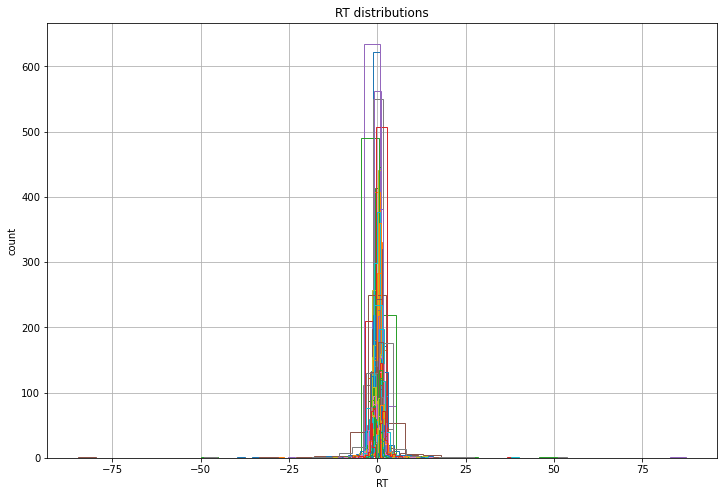

In [20]:
data = hddm.utils.flip_errors(mydata) #mydata.copy() #
#data = mydata.copy()
fig = plt.figure(figsize=[12,8])
ax = fig.add_subplot(111, xlabel='RT', ylabel='count', title='RT distributions')
for i, subj_data in data.groupby('subj_idx'):
    subj_data.rt.hist(bins=20, histtype='step', ax=ax)

In [18]:
def run_model(m, model_filename, model_name, n_samples):
    import pickle
    #print("finding starting values")
    #try:
    #    m.find_starting_values() # this should help the sampling
    #except:
    #    print('finding starting samples has failed')

    #print("begin sampling")
    m.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')
    #m.save(model_filename) # save the model to disk
    return m
             

In [19]:
def savemodel_idx(m, model_filename):
    out_m = dict()
    out_m['dic'] = [m.dic]
    out_m['aic'] = [aic(m)]
    out_m['bic'] = [bic(m)]
    out_df = pd.DataFrame(out_m)
    out_df.to_csv(model_filename+'_params')

# Regression models

## 3 reps experiment

In [23]:
dat = mydata[mydata.exp_ID == '3reps']
dat.reset_index(inplace = True, drop = True)
dat['subj_idx'] = dat['subj_idx'].cat.remove_unused_categories()


<ipython-input-23-2414357bfbeb>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subj_idx'] = dat['subj_idx'].cat.remove_unused_categories()


__Model with weight for each stimulus__

In [25]:
z_reg = {'model': 'z ~ 1 + response1 * C(nrep)', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1abs:C(nrep) + G2abs:C(nrep) +G3abs:C(nrep)+G4abs:C(nrep)+G5abs:C(nrep)+G6abs:C(nrep)', 'link_func': lambda x: x}
reg_descr = [z_reg, v_reg]


In [26]:
n_samples = 2000
model_name = 'stimcoding_weights'
exp_ID = '3reps' 

In [20]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

Run model and save it

In [220]:
m_reg_3repstimweights = hddm.HDDMRegressor(dat, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).

m_reg_3repstimweights.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

m_reg_3repstimweights.save(model_filename+'_fm.db') # save the model to disk

Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_C(nrep)[T.2]', 'z_response1', 'z_response1:C(nrep)[T.1]', 'z_response1:C(nrep)[T.2]']
Adding these covariates:
['v_Intercept', 'v_G1abs:C(nrep)[0]', 'v_G1abs:C(nrep)[1]', 'v_G1abs:C(nrep)[2]', 'v_G2abs:C(nrep)[0]', 'v_G2abs:C(nrep)[1]', 'v_G2abs:C(nrep)[2]', 'v_G3abs:C(nrep)[0]', 'v_G3abs:C(nrep)[1]', 'v_G3abs:C(nrep)[2]', 'v_G4abs:C(nrep)[0]', 'v_G4abs:C(nrep)[1]', 'v_G4abs:C(nrep)[2]', 'v_G5abs:C(nrep)[0]', 'v_G5abs:C(nrep)[1]', 'v_G5abs:C(nrep)[2]', 'v_G6abs:C(nrep)[0]', 'v_G6abs:C(nrep)[1]', 'v_G6abs:C(nrep)[2]']
 [-----------------100%-----------------] 2001 of 2000 complete in 41037.7 secWARNING: Will not save custom link functions.


In [2]:
m_reg_3repstimweights.print_stats()

NameError: name 'm_reg_3repstimweights' is not defined

__Model with weight for each stimulus as a function of dv distance to previous decision__

In [27]:
z_reg = {'model': 'z ~ 1 + response1 * C(nrep)', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1sim:C(nrep) + G2sim:C(nrep) +G3sim:C(nrep)+G4sim:C(nrep)+G5sim:C(nrep)+G6sim:C(nrep)', 'link_func': lambda x: x}
reg_descr = [z_reg, v_reg]

In [28]:
n_samples = 2000
model_name = 'stimcoding_diffprev'
exp_ID = '3reps' 

In [29]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [30]:

m_reg_3repsprevabs = hddm.HDDMRegressor(dat, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).

m_reg_3repsprevabs.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

m_reg_3repsprevabs.save(model_filename+'_fm.db') # save the model to disk

Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_C(nrep)[T.2]', 'z_response1', 'z_response1:C(nrep)[T.1]', 'z_response1:C(nrep)[T.2]']
Adding these covariates:
['v_Intercept', 'v_G1sim:C(nrep)[0]', 'v_G1sim:C(nrep)[1]', 'v_G1sim:C(nrep)[2]', 'v_G2sim:C(nrep)[0]', 'v_G2sim:C(nrep)[1]', 'v_G2sim:C(nrep)[2]', 'v_G3sim:C(nrep)[0]', 'v_G3sim:C(nrep)[1]', 'v_G3sim:C(nrep)[2]', 'v_G4sim:C(nrep)[0]', 'v_G4sim:C(nrep)[1]', 'v_G4sim:C(nrep)[2]', 'v_G5sim:C(nrep)[0]', 'v_G5sim:C(nrep)[1]', 'v_G5sim:C(nrep)[2]', 'v_G6sim:C(nrep)[0]', 'v_G6sim:C(nrep)[1]', 'v_G6sim:C(nrep)[2]']
 [-----------------100%-----------------] 2001 of 2000 complete in 38409.0 secWARNING: Will not save custom link functions.


In [39]:
m_reg_3repsprevabs.print_stats()

                                mean         std         2.5q         25q         50q         75q      97.5q       mc err
a                            1.58881   0.0727338      1.44793     1.54197     1.59337     1.63912    1.72322   0.00399429
a_std                       0.361632   0.0584875     0.272368    0.319102    0.356677    0.396976   0.491846   0.00319451
a_subj.26                     1.7169   0.0530113      1.61881     1.67852     1.71612     1.75027    1.82079   0.00404632
a_subj.27                    1.25488   0.0277703      1.20388     1.23473     1.25485     1.27551    1.30716   0.00150654
a_subj.28                    1.37391   0.0299977      1.31971     1.35397      1.3744     1.39276    1.42951   0.00175154
a_subj.29                     1.6072   0.0371898      1.54234     1.57898     1.60697     1.63375    1.67505   0.00222282
a_subj.30                    1.34597   0.0327987      1.28319     1.32111     1.34608     1.36873       1.41   0.00213487
a_subj.31               

Plotting a
Plotting a_std
Plotting t
Plotting t_std
Plotting z_Intercept
Plotting z_Intercept_std
Plotting z_C(nrep)[T.1]
Plotting z_C(nrep)[T.2]
Plotting z_response1
Plotting z_response1:C(nrep)[T.1]
Plotting z_response1:C(nrep)[T.2]
Plotting v_Intercept
Plotting v_Intercept_std
Plotting v_G1sim:C(nrep)[0]
Plotting v_G1sim:C(nrep)[1]
Plotting v_G1sim:C(nrep)[2]
Plotting v_G2sim:C(nrep)[0]
Plotting v_G2sim:C(nrep)[1]
Plotting v_G2sim:C(nrep)[2]
Plotting v_G3sim:C(nrep)[0]
Plotting v_G3sim:C(nrep)[1]


/opt/conda/lib/python3.8/site-packages/pymc/Matplot.py:432: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  figure(figsize=(10, 6))


Plotting v_G3sim:C(nrep)[2]
Plotting v_G4sim:C(nrep)[0]
Plotting v_G4sim:C(nrep)[1]
Plotting v_G4sim:C(nrep)[2]
Plotting v_G5sim:C(nrep)[0]
Plotting v_G5sim:C(nrep)[1]
Plotting v_G5sim:C(nrep)[2]
Plotting v_G6sim:C(nrep)[0]
Plotting v_G6sim:C(nrep)[1]
Plotting v_G6sim:C(nrep)[2]


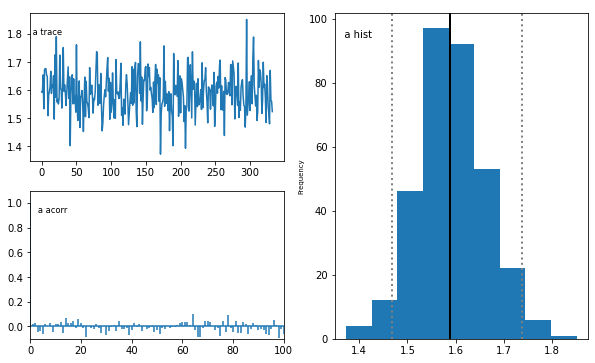

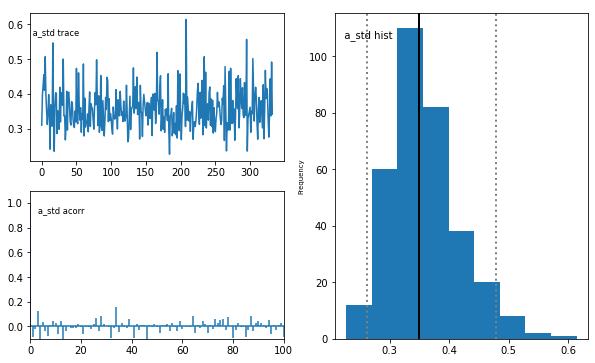

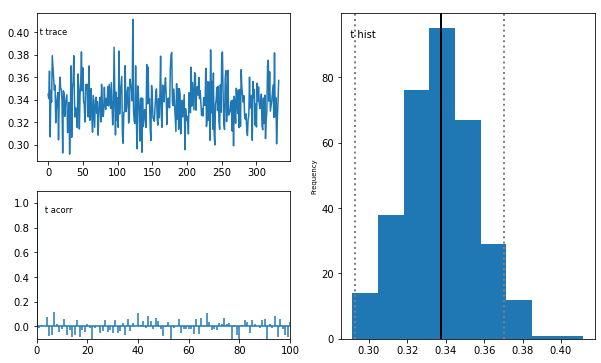

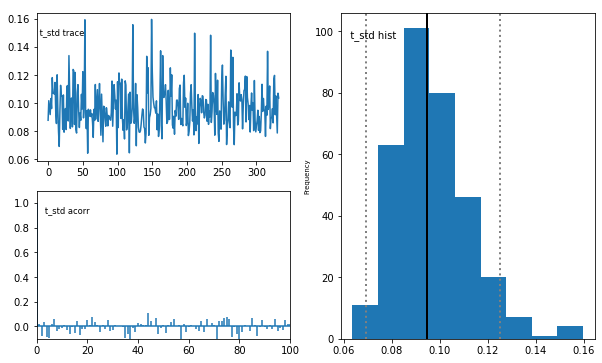

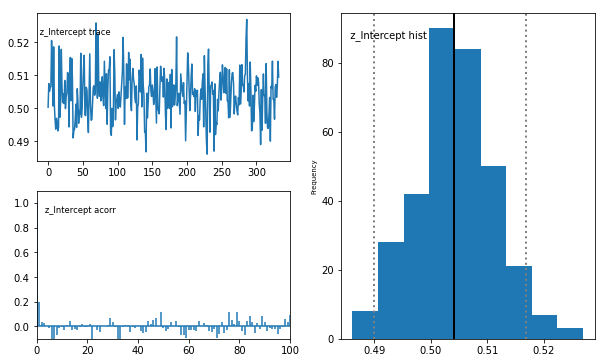

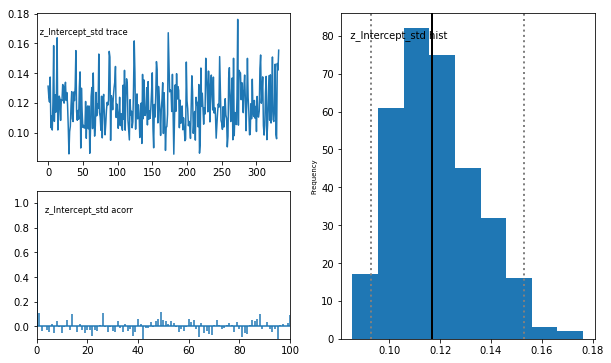

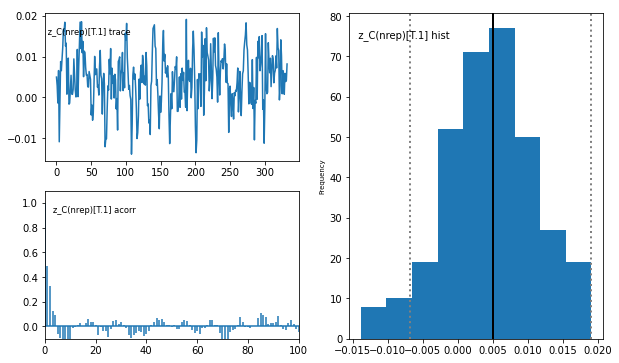

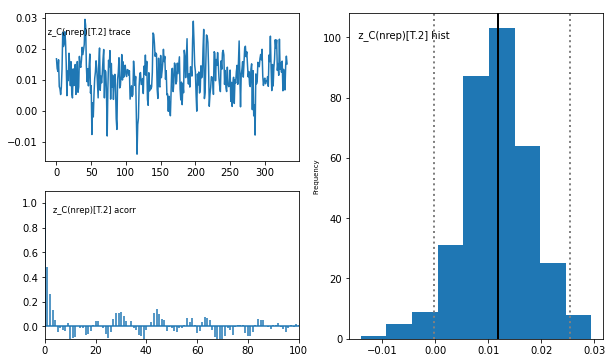

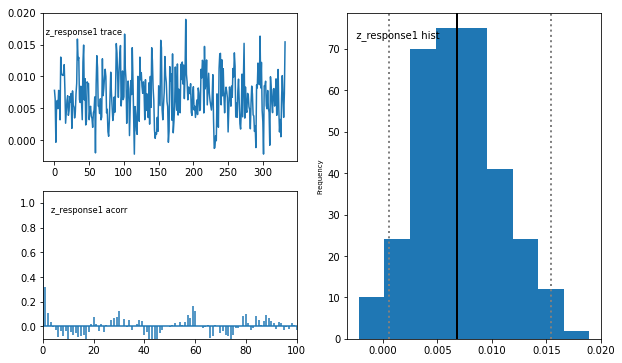

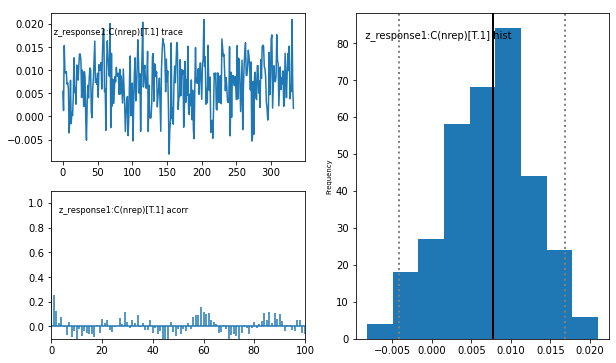

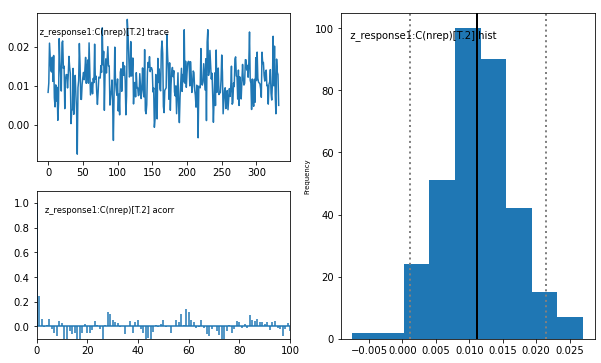

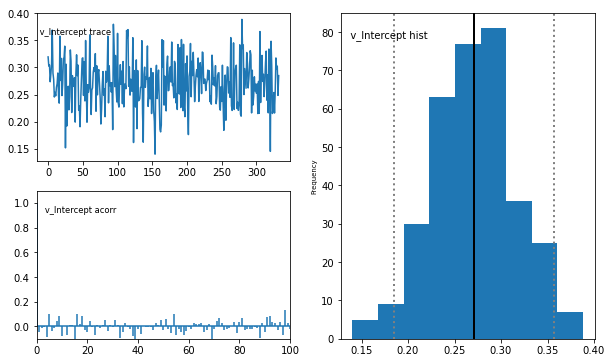

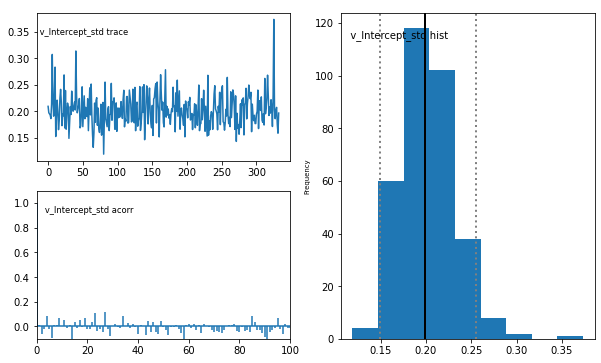

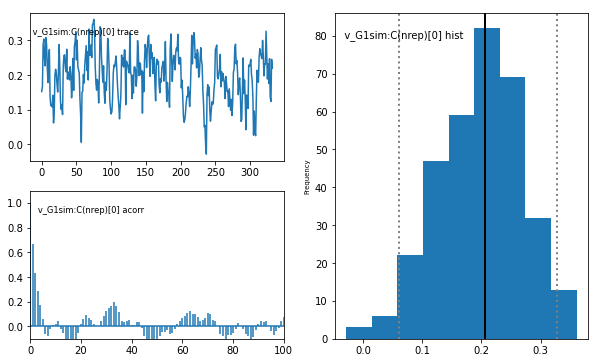

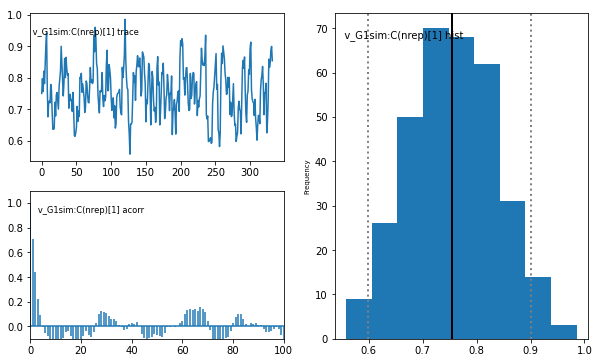

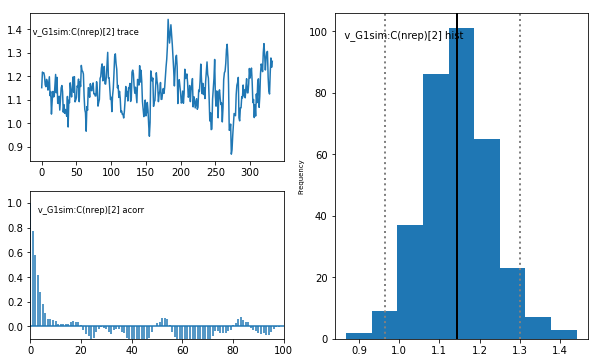

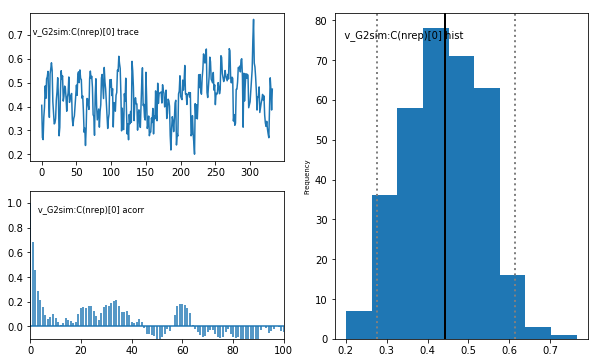

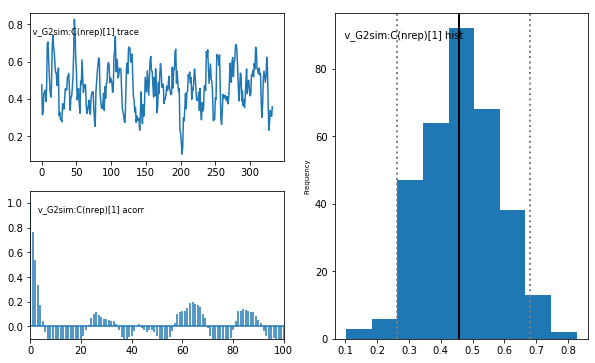

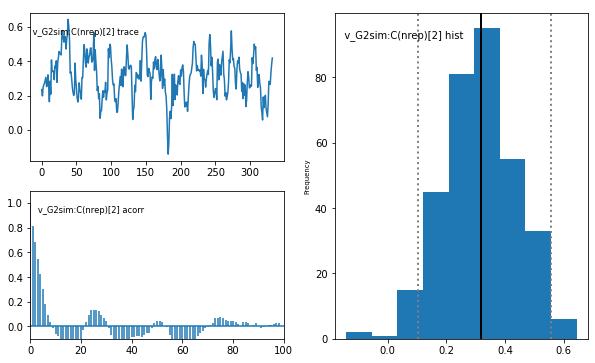

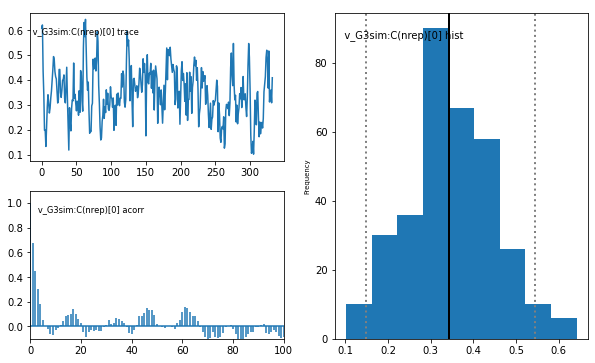

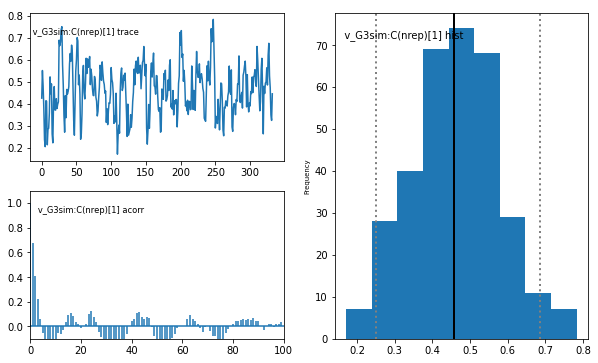

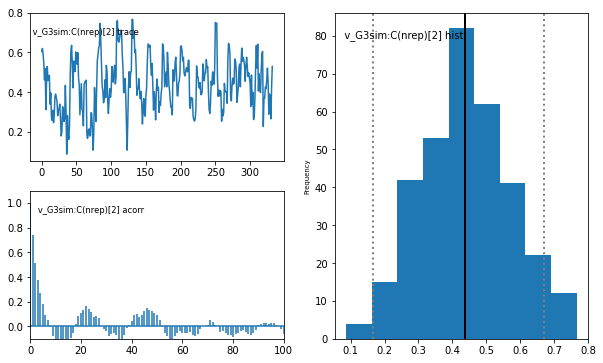

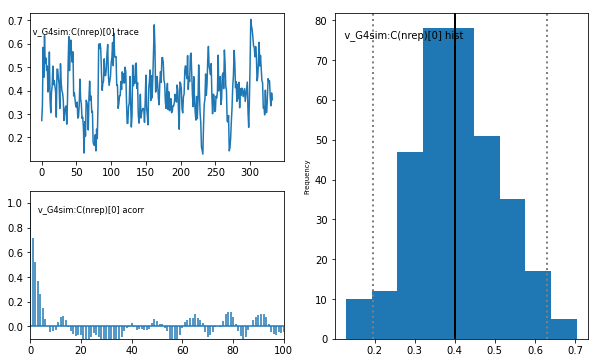

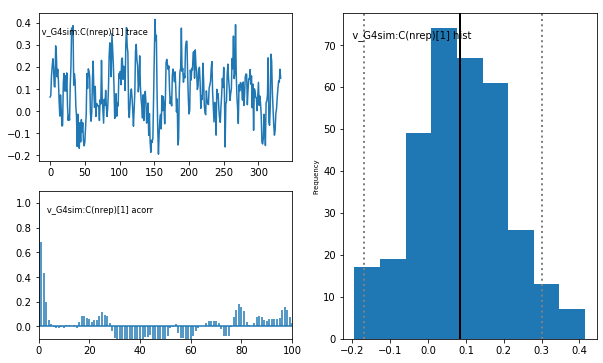

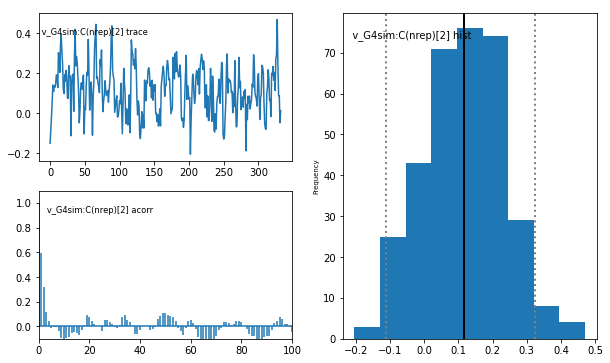

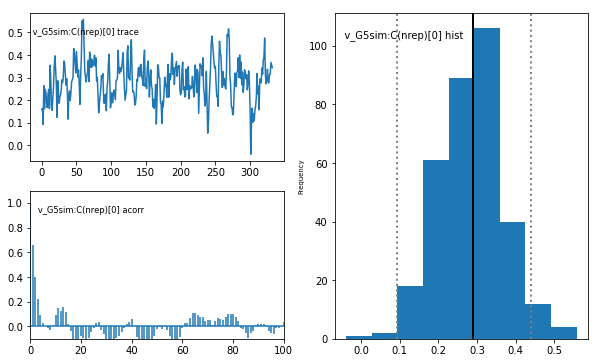

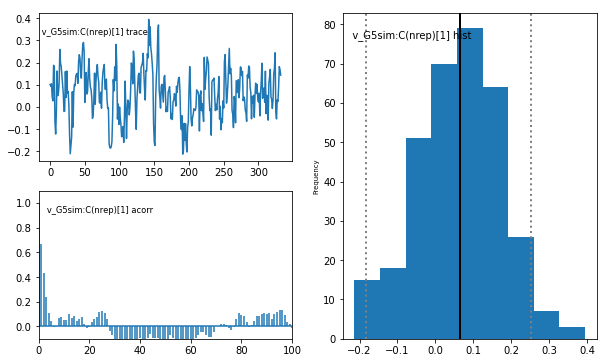

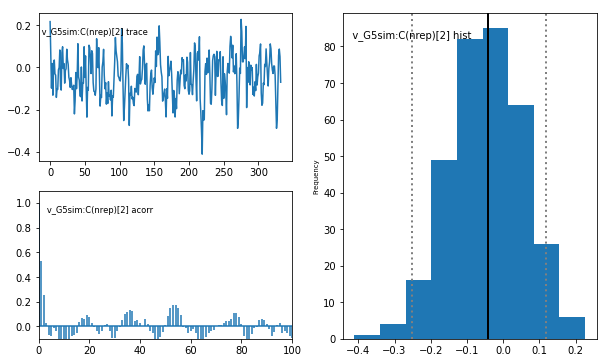

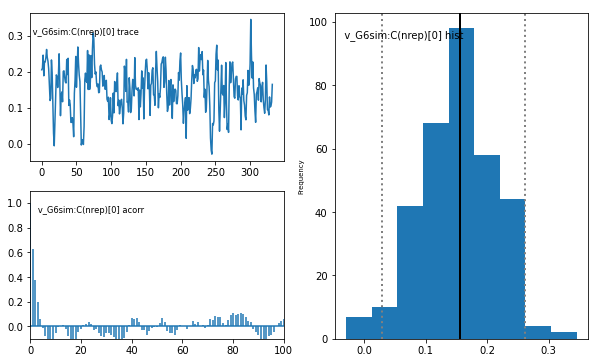

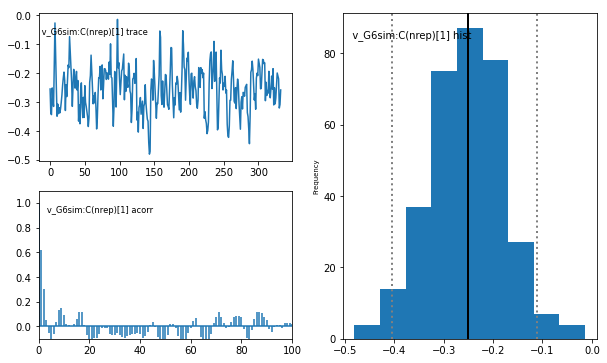

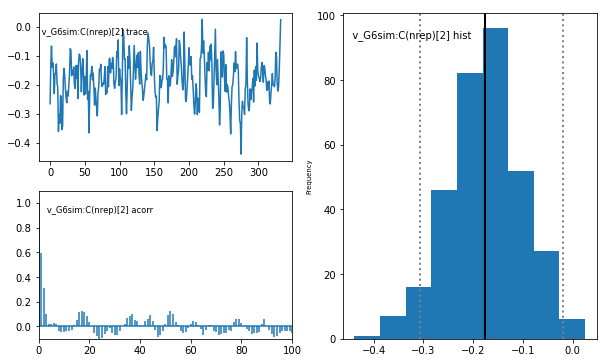

In [185]:
m_reg_3repsprevabs.plot_posteriors()

## 2 CJ experiment

In [16]:
dat = mydata[mydata.exp_ID == 'CJ']
dat.reset_index(inplace = True, drop = True)
dat['nrep'] = dat['nrep'].cat.remove_unused_categories()
dat['subj_idx'] = dat['subj_idx'].cat.remove_unused_categories()
exp_ID = 'CJ' 

<ipython-input-16-6c30db233eba>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['nrep'] = dat['nrep'].cat.remove_unused_categories()
<ipython-input-16-6c30db233eba>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subj_idx'] = dat['subj_idx'].cat.remove_unused_categories()


__Model with weight for each stimulus__

In [50]:
def z_link_func(x, data=dat):
    stim = (np.asarray(dmatrix('0 + C(s, [[0], [1]])',
                              {'s': data.stimulus.loc[x.index]},return_type='dataframe'))
    )
    # Apply z = (1 - x) to flip them along 0.5
    z_flip = np.subtract(stim, x.to_frame())
    # The above inverts those values we do not want to flip,
    # so invert them back
    z_flip[stim == 0] *= -1
    return z_flip

In [25]:
z_reg = {'model': 'z ~ 1 + response1 * C(nrep)', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1abs:C(nrep) + G2abs:C(nrep) +G3abs:C(nrep)+G4abs:C(nrep)+G5abs:C(nrep)+G6abs:C(nrep)', 'link_func': lambda x: x}
reg_descr = [z_reg, v_reg]


In [26]:
n_samples = 2000
model_name = 'stimcoding_weights'
exp_ID = 'CJ' 

In [27]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

Run model and save it

In [28]:
m_reg_CJtimweights = hddm.HDDMRegressor(dat, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).


Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_response1', 'z_response1:C(nrep)[T.1]']
Adding these covariates:
['v_Intercept', 'v_G1abs:C(nrep)[0]', 'v_G1abs:C(nrep)[1]', 'v_G2abs:C(nrep)[0]', 'v_G2abs:C(nrep)[1]', 'v_G3abs:C(nrep)[0]', 'v_G3abs:C(nrep)[1]', 'v_G4abs:C(nrep)[0]', 'v_G4abs:C(nrep)[1]', 'v_G5abs:C(nrep)[0]', 'v_G5abs:C(nrep)[1]', 'v_G6abs:C(nrep)[0]', 'v_G6abs:C(nrep)[1]']


In [54]:

m_reg_CJtimweights.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

m_reg_CJtimweights.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 18664.0 secWARNING: Will not save custom link functions.


In [55]:
m_reg_CJtimweights.print_stats()

                                mean         std         2.5q         25q        50q        75q       97.5q       mc err
a                            1.72515   0.0266613      1.67383     1.70748    1.72347    1.74155     1.78465   0.00162946
a_std                       0.172756   0.0209224     0.135587    0.159399    0.17056    0.18427    0.217465   0.00124954
a_subj.107                   1.61942   0.0486231       1.5135     1.59076    1.62173    1.65031     1.71455   0.00296357
a_subj.108                   1.67372     0.04633      1.59212      1.6433     1.6675    1.70318     1.75916   0.00245202
a_subj.109                   1.75185   0.0494292      1.65226     1.71577    1.75387    1.78331     1.84738   0.00288707
a_subj.110                   1.93057   0.0566329      1.82004      1.8955    1.92809    1.96969     2.04074   0.00345843
a_subj.111                   1.91825    0.059378      1.80991     1.87481    1.91472    1.96201     2.04567   0.00331672
a_subj.112                   1.6

__Model with weight for each stimulus as a function of dv distance to previous decision__

In [172]:
z_reg = {'model': 'z ~ 1 + response1 * C(nrep)', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1sim:C(nrep) + G2sim:C(nrep) +G3sim:C(nrep)+G4sim:C(nrep)+G5sim:C(nrep)+G6sim:C(nrep)', 'link_func': lambda x: x}
reg_descr = [z_reg, v_reg]

In [173]:
n_samples = 2000
model_name = 'stimcoding_diffprev'


In [174]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [175]:
m_reg_CJprevabs = hddm.HDDMRegressor(dat, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).


Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_response1', 'z_response1:C(nrep)[T.1]']
Adding these covariates:
['v_Intercept', 'v_G1sim:C(nrep)[0]', 'v_G1sim:C(nrep)[1]', 'v_G2sim:C(nrep)[0]', 'v_G2sim:C(nrep)[1]', 'v_G3sim:C(nrep)[0]', 'v_G3sim:C(nrep)[1]', 'v_G4sim:C(nrep)[0]', 'v_G4sim:C(nrep)[1]', 'v_G5sim:C(nrep)[0]', 'v_G5sim:C(nrep)[1]', 'v_G6sim:C(nrep)[0]', 'v_G6sim:C(nrep)[1]']


In [176]:
m_reg_CJprevabs.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

m_reg_CJprevabs.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 18184.6 secWARNING: Will not save custom link functions.


In [177]:
m_reg_CJprevabs.print_stats()


                                mean         std        2.5q          25q         50q         75q       97.5q       mc err
a                            1.83249   0.0284024     1.77811      1.81413     1.83128     1.85088     1.88794   0.00171411
a_std                       0.190409   0.0241537    0.148366     0.173879    0.187867    0.205256     0.24808   0.00141316
a_subj.107                   1.68823   0.0534572     1.58582      1.65309     1.68591     1.72151     1.79709   0.00338101
a_subj.108                   1.77176   0.0496533     1.68407      1.73646      1.7707     1.80357      1.8774   0.00308343
a_subj.109                   1.86432   0.0548734     1.75751      1.82419     1.86096     1.90285     1.97024   0.00337364
a_subj.110                   2.02113   0.0631796     1.91143       1.9737     2.02044      2.0683     2.13698   0.00377506
a_subj.111                   2.07184   0.0718129      1.9432      2.02081     2.07088     2.11948     2.22275   0.00431906
a_subj.112      

__Modeling the effect of similarity for repeated sequences__

In [33]:
z_reg = {'model': 'z ~ 1 + response1 * C(nrep)', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1sim:C(nrep) + G2sim:C(nrep) +G3sim:C(nrep)+G4sim:C(nrep)+G5sim:C(nrep)+G6sim:C(nrep)', 'link_func': lambda x: x}
reg_descr = [z_reg, v_reg]

In [34]:
n_samples = 2000
model_name = 'stimcoding_diff_prev_repeat'


In [35]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [36]:
dat_rep = dat[dat.trial_type == 'repeat']

In [37]:
m_reg_CJprevREP = hddm.HDDMRegressor(dat_rep, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).


Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_response1', 'z_response1:C(nrep)[T.1]']
Adding these covariates:
['v_Intercept', 'v_G1sim:C(nrep)[0]', 'v_G1sim:C(nrep)[1]', 'v_G2sim:C(nrep)[0]', 'v_G2sim:C(nrep)[1]', 'v_G3sim:C(nrep)[0]', 'v_G3sim:C(nrep)[1]', 'v_G4sim:C(nrep)[0]', 'v_G4sim:C(nrep)[1]', 'v_G5sim:C(nrep)[0]', 'v_G5sim:C(nrep)[1]', 'v_G6sim:C(nrep)[0]', 'v_G6sim:C(nrep)[1]']


In [38]:
m_reg_CJprevREP.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

m_reg_CJprevREP.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 16563.3 secWARNING: Will not save custom link functions.


In [39]:
m_reg_CJprevREP.print_stats()


                                mean         std        2.5q         25q         50q        75q       97.5q       mc err
a                            1.85179    0.037065     1.77996      1.8277     1.85007     1.8744     1.92906   0.00213158
a_std                       0.229919   0.0302917    0.177937    0.208316    0.228318   0.248484    0.297328    0.0018349
a_subj.107                   1.63025   0.0638759     1.51774     1.58278     1.62999    1.67463     1.76609   0.00387027
a_subj.108                   1.91079   0.0728549     1.76807     1.86423     1.91009    1.95778     2.05891   0.00434874
a_subj.109                   1.79315   0.0715209     1.65627     1.74314     1.79534    1.83878     1.94627   0.00411864
a_subj.110                   2.06171   0.0918472     1.88775     1.99382     2.06265    2.11753     2.25313   0.00555722
a_subj.111                   2.22172    0.116688     2.01486     2.14284     2.21763    2.29966     2.43821   0.00746005
a_subj.112                    1.

__Modeling the effect of similarity for nonrepeated sequences__

In [40]:
z_reg = {'model': 'z ~ 1 + response1 * C(nrep)', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1sim:C(nrep) + G2sim:C(nrep) +G3sim:C(nrep)+G4sim:C(nrep)+G5sim:C(nrep)+G6sim:C(nrep)', 'link_func': lambda x: x}
reg_descr = [z_reg, v_reg]

In [41]:
n_samples = 2000
model_name = 'stimcoding_diff_prev_nonrepeat'


In [42]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [43]:
dat_nonrep = dat[dat.trial_type == 'nonrepeat']

In [45]:
m_reg_CJprevNONREP = hddm.HDDMRegressor(dat_nonrep, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).


Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_response1', 'z_response1:C(nrep)[T.1]']
Adding these covariates:
['v_Intercept', 'v_G1sim:C(nrep)[0]', 'v_G1sim:C(nrep)[1]', 'v_G2sim:C(nrep)[0]', 'v_G2sim:C(nrep)[1]', 'v_G3sim:C(nrep)[0]', 'v_G3sim:C(nrep)[1]', 'v_G4sim:C(nrep)[0]', 'v_G4sim:C(nrep)[1]', 'v_G5sim:C(nrep)[0]', 'v_G5sim:C(nrep)[1]', 'v_G6sim:C(nrep)[0]', 'v_G6sim:C(nrep)[1]']


In [46]:
m_reg_CJprevNONREP.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

m_reg_CJprevNONREP.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 16827.6 secWARNING: Will not save custom link functions.


In [47]:
m_reg_CJprevNONREP.print_stats()


                                mean         std         2.5q         25q         50q         75q      97.5q       mc err
a                            1.82346   0.0322509      1.75774     1.80453      1.8251     1.84522    1.88285   0.00203713
a_std                       0.191202   0.0261751      0.14712     0.17443    0.189548    0.205378   0.250517   0.00161504
a_subj.107                   1.75548   0.0721058      1.61356     1.70587     1.75205     1.80941    1.88684   0.00442255
a_subj.108                   1.64703   0.0691866      1.52558     1.59839     1.64087     1.69471    1.79239   0.00384006
a_subj.109                   1.90847   0.0799725      1.76822     1.84844     1.90459     1.95588    2.06994    0.0045168
a_subj.110                   1.94773   0.0795347      1.77822      1.8974     1.94926     2.00063    2.10622   0.00499925
a_subj.111                   1.95203   0.0902222      1.78381      1.8853     1.95243     2.01655    2.11986    0.0055067
a_subj.112              

__Effect of confidence__

In [56]:
def z_link_func(x, data=dat):
    stim = (np.asarray(dmatrix('0 + C(s, [[0], [1]])',
                              {'s': data.stimulus.loc[x.index]},return_type='dataframe'))
    )
    # Apply z = (1 - x) to flip them along 0.5
    z_flip = np.subtract(stim, x.to_frame())
    # The above inverts those values we do not want to flip,
    # so invert them back
    z_flip[stim == 0] *= -1
    return z_flip

In [87]:

z_reg = {'model': 'z ~ 1 + C(nrep)*response1 + C(nrep):response1:Confidence1', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1sim:C(nrep) + G1sim:C(nrep):Confidence1 + G2sim:C(nrep) + G2sim:C(nrep):Confidence1 + G3sim:C(nrep) + G3sim:C(nrep):Confidence1+G4sim:C(nrep) +G4sim:C(nrep):Confidence1+G5sim:C(nrep) +G5sim:C(nrep):Confidence1+G6sim:C(nrep) +G6sim:C(nrep):Confidence1', 'link_func': lambda x: x}
reg_descr = [v_reg,z_reg]

In [92]:
n_samples = 2000
model_name = 'z_v_prevrespconf'
exp_ID = 'CJ' 

In [93]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

Run model and save it

In [94]:
dat = dat.dropna(subset=['Confidence1'])

In [95]:
z_v_prevrespconf = hddm.HDDMRegressor(dat, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).


Adding these covariates:
['v_Intercept', 'v_G1sim:C(nrep)[0]', 'v_G1sim:C(nrep)[1]', 'v_G1sim:C(nrep)[0]:Confidence1', 'v_G1sim:C(nrep)[1]:Confidence1', 'v_G2sim:C(nrep)[0]', 'v_G2sim:C(nrep)[1]', 'v_G2sim:C(nrep)[0]:Confidence1', 'v_G2sim:C(nrep)[1]:Confidence1', 'v_G3sim:C(nrep)[0]', 'v_G3sim:C(nrep)[1]', 'v_G3sim:C(nrep)[0]:Confidence1', 'v_G3sim:C(nrep)[1]:Confidence1', 'v_G4sim:C(nrep)[0]', 'v_G4sim:C(nrep)[1]', 'v_G4sim:C(nrep)[0]:Confidence1', 'v_G4sim:C(nrep)[1]:Confidence1', 'v_G5sim:C(nrep)[0]', 'v_G5sim:C(nrep)[1]', 'v_G5sim:C(nrep)[0]:Confidence1', 'v_G5sim:C(nrep)[1]:Confidence1', 'v_G6sim:C(nrep)[0]', 'v_G6sim:C(nrep)[1]', 'v_G6sim:C(nrep)[0]:Confidence1', 'v_G6sim:C(nrep)[1]:Confidence1']
Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_response1', 'z_C(nrep)[T.1]:response1', 'z_C(nrep)[0]:response1:Confidence1', 'z_C(nrep)[1]:response1:Confidence1']


In [96]:

z_v_prevrespconf.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')
z_v_prevrespconf.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 29978.4 sec

In [99]:
z_v_prevrespconf.print_stats()

                                          mean         std         2.5q          25q         50q         75q      97.5q       mc err
a                                      1.83922   0.0306046      1.78214      1.81743     1.83835      1.8616    1.89837   0.00183116
a_std                                 0.188358   0.0230673      0.14701     0.171771    0.185191    0.201933   0.241805   0.00142768
a_subj.107                             1.68195   0.0562352      1.57122      1.64161     1.68495     1.71701    1.79127   0.00354946
a_subj.108                             1.78281   0.0495122       1.6823      1.75068     1.78112     1.81717    1.88036   0.00322615
a_subj.109                             1.87439   0.0542675      1.77363      1.83431     1.87098     1.91033    1.98891   0.00297709
a_subj.110                             2.01637   0.0629776      1.89776      1.97222     2.01291     2.06518    2.13739   0.00425004
a_subj.111                             2.07273   0.0694492      1.939

__Effect of metaDprime__

In [52]:
def z_link_func(x, data=dat):
    stim = (np.asarray(dmatrix('0 + C(s, [[0], [1]])',
                              {'s': data.stimulus.loc[x.index]},return_type='dataframe'))
    )
    # Apply z = (1 - x) to flip them along 0.5
    z_flip = np.subtract(stim, x.to_frame())
    # The above inverts those values we do not want to flip,
    # so invert them back
    z_flip[stim == 0] *= -1
    return z_flip

In [ ]:
Responses ~  dv  + response1 +  response1 *metad + response1:metad: accuracy1  + 

In [100]:
z_reg = {'model': 'z ~ 1 + response1 * C(nrep)+ response1 : C(nrep):metad', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1sim:C(nrep) + G1sim:C(nrep):metad + G2sim:C(nrep) + G2sim:C(nrep):metad + G3sim:C(nrep) + G3sim:C(nrep):metad+G4sim:C(nrep) +G4sim:C(nrep):metad+G5sim:C(nrep) +G5sim:C(nrep):metad+G6sim:C(nrep) +G6sim:C(nrep):metad', 'link_func': lambda x: x}
reg_descr = [v_reg,z_reg]

In [101]:
n_samples = 2000
model_name = 'z_v_prevrespmetad'
exp_ID = 'CJ' 

In [102]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

Run model and save it

In [103]:
dat = dat.dropna(subset=['metad'])

In [104]:
z_v_prevrespmetad = hddm.HDDMRegressor(dat, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).


Adding these covariates:
['v_Intercept', 'v_G1sim:C(nrep)[0]', 'v_G1sim:C(nrep)[1]', 'v_G1sim:C(nrep)[0]:metad', 'v_G1sim:C(nrep)[1]:metad', 'v_G2sim:C(nrep)[0]', 'v_G2sim:C(nrep)[1]', 'v_G2sim:C(nrep)[0]:metad', 'v_G2sim:C(nrep)[1]:metad', 'v_G3sim:C(nrep)[0]', 'v_G3sim:C(nrep)[1]', 'v_G3sim:C(nrep)[0]:metad', 'v_G3sim:C(nrep)[1]:metad', 'v_G4sim:C(nrep)[0]', 'v_G4sim:C(nrep)[1]', 'v_G4sim:C(nrep)[0]:metad', 'v_G4sim:C(nrep)[1]:metad', 'v_G5sim:C(nrep)[0]', 'v_G5sim:C(nrep)[1]', 'v_G5sim:C(nrep)[0]:metad', 'v_G5sim:C(nrep)[1]:metad', 'v_G6sim:C(nrep)[0]', 'v_G6sim:C(nrep)[1]', 'v_G6sim:C(nrep)[0]:metad', 'v_G6sim:C(nrep)[1]:metad']
Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_response1', 'z_response1:C(nrep)[T.1]', 'z_response1:C(nrep)[0]:metad', 'z_response1:C(nrep)[1]:metad']


In [105]:
z_v_prevrespmetad.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

z_v_prevrespmetad.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 29454.8 secWARNING: Will not save custom link functions.


In [106]:
z_v_prevrespmetad.print_stats()

                                    mean         std         2.5q         25q         50q         75q      97.5q       mc err
a                                1.83281   0.0303641      1.77919     1.81236     1.83117     1.85092    1.89544   0.00164073
a_std                           0.189402   0.0220117     0.148673    0.175205    0.187981    0.203065   0.231362   0.00119196
a_subj.107                       1.67522   0.0550889      1.56451     1.63838     1.67342     1.71162    1.78413    0.0033362
a_subj.108                       1.77391   0.0478571      1.68168     1.74002     1.77395      1.8076    1.86463   0.00251201
a_subj.109                       1.87248   0.0595863      1.77201     1.83406     1.86809     1.90862     2.0029   0.00347808
a_subj.110                       2.02808   0.0682826      1.90096     1.98296     2.02847      2.0711    2.16557   0.00425343
a_subj.111                        2.0704   0.0689037      1.94185     2.02253     2.06643     2.11574    2.21141   0.0

Plotting a
Plotting a_std
Plotting t
Plotting t_std
Plotting v_Intercept
Plotting v_Intercept_std
Plotting v_G1sim:C(nrep)[0]
Plotting v_G1sim:C(nrep)[1]
Plotting v_G1sim:C(nrep)[0]:metad
Plotting v_G1sim:C(nrep)[1]:metad
Plotting v_G2sim:C(nrep)[0]
Plotting v_G2sim:C(nrep)[1]
Plotting v_G2sim:C(nrep)[0]:metad
Plotting v_G2sim:C(nrep)[1]:metad
Plotting v_G3sim:C(nrep)[0]
Plotting v_G3sim:C(nrep)[1]
Plotting v_G3sim:C(nrep)[0]:metad
Plotting v_G3sim:C(nrep)[1]:metad
Plotting v_G4sim:C(nrep)[0]
Plotting v_G4sim:C(nrep)[1]
Plotting v_G4sim:C(nrep)[0]:metad
Plotting v_G4sim:C(nrep)[1]:metad
Plotting v_G5sim:C(nrep)[0]


/opt/conda/lib/python3.8/site-packages/pymc/Matplot.py:432: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  figure(figsize=(10, 6))


Plotting v_G5sim:C(nrep)[1]
Plotting v_G5sim:C(nrep)[0]:metad
Plotting v_G5sim:C(nrep)[1]:metad
Plotting v_G6sim:C(nrep)[0]
Plotting v_G6sim:C(nrep)[1]
Plotting v_G6sim:C(nrep)[0]:metad
Plotting v_G6sim:C(nrep)[1]:metad
Plotting z_Intercept
Plotting z_Intercept_std
Plotting z_C(nrep)[T.1]
Plotting z_response1
Plotting z_response1:C(nrep)[T.1]
Plotting z_response1:C(nrep)[0]:metad
Plotting z_response1:C(nrep)[1]:metad


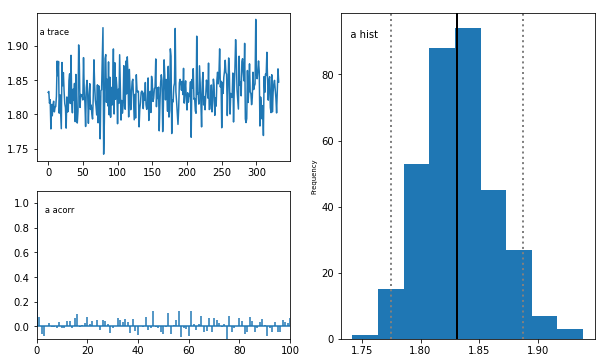

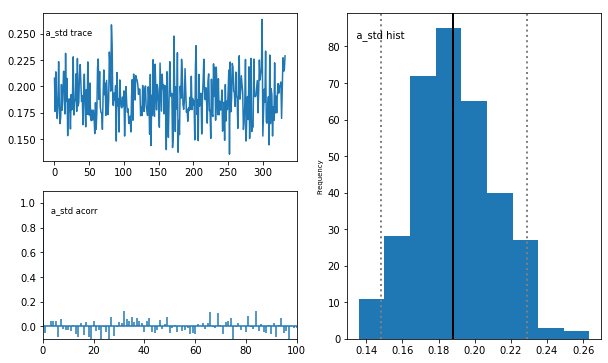

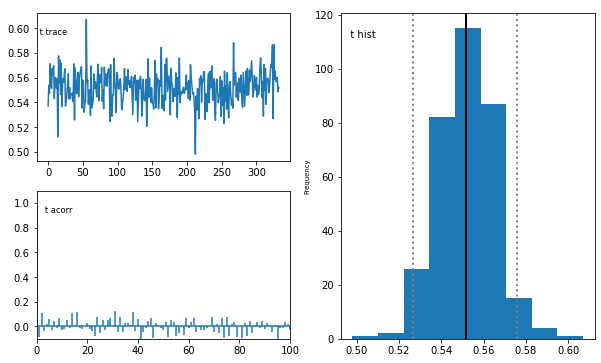

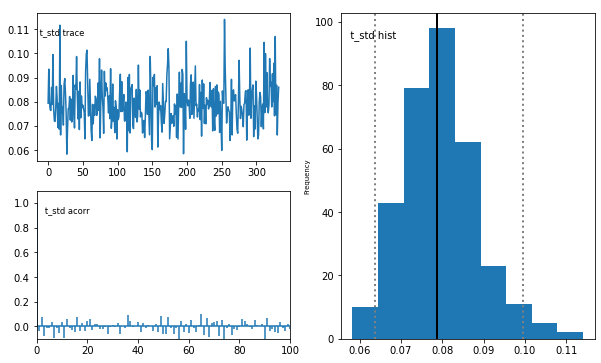

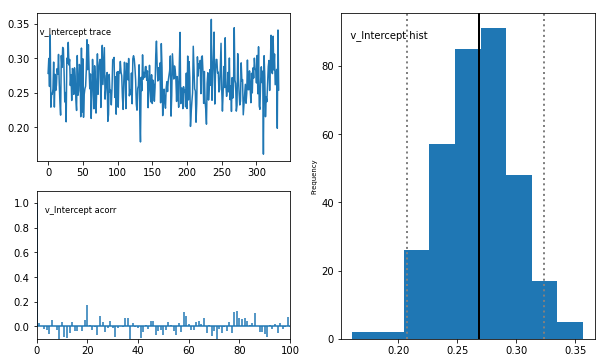

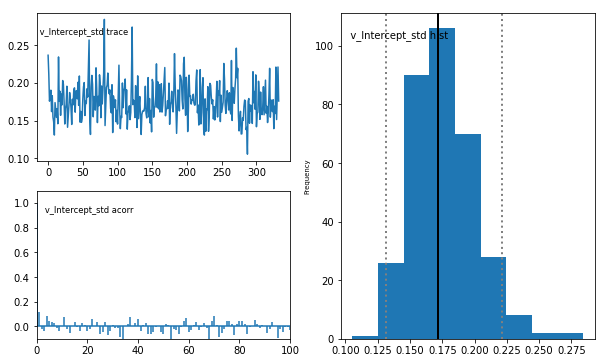

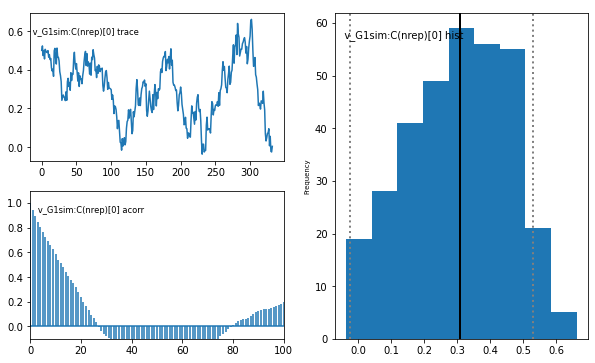

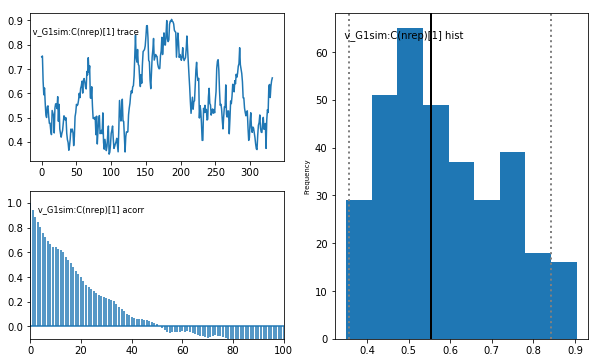

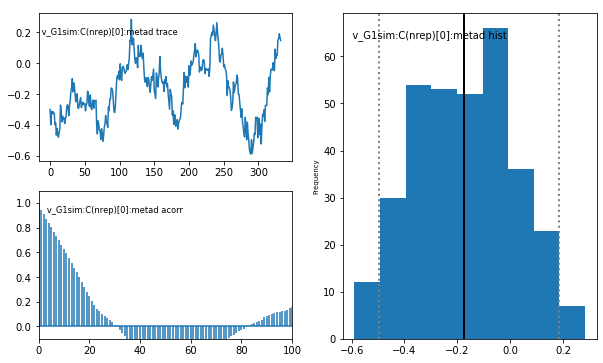

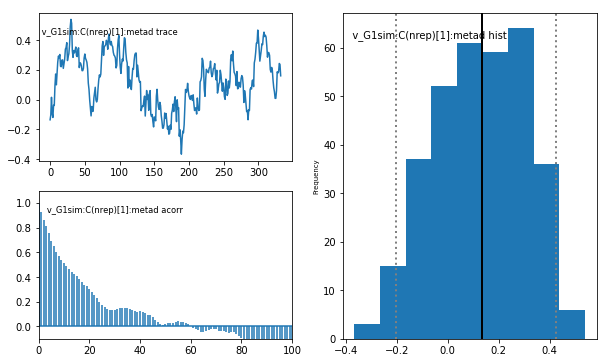

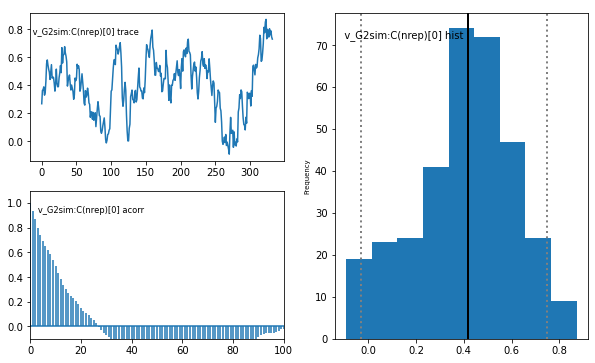

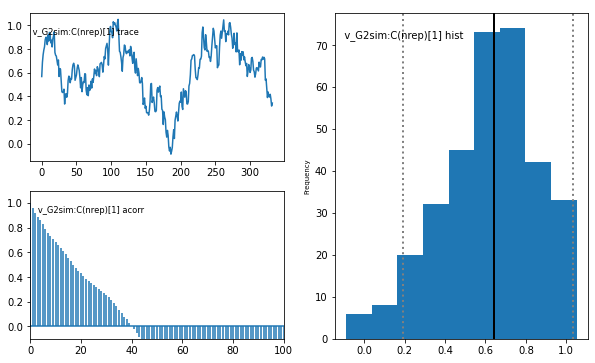

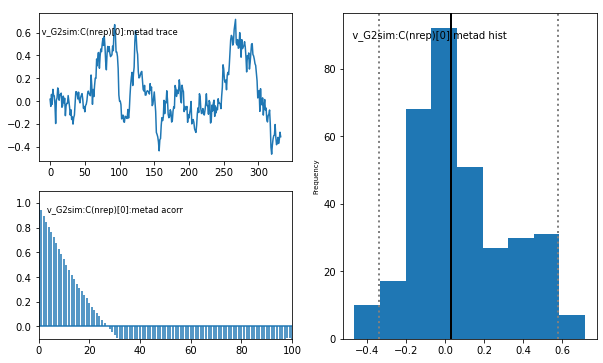

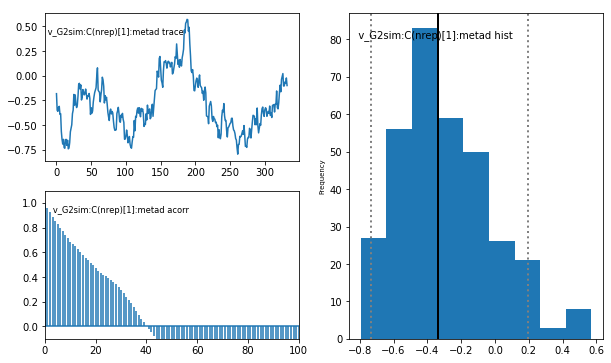

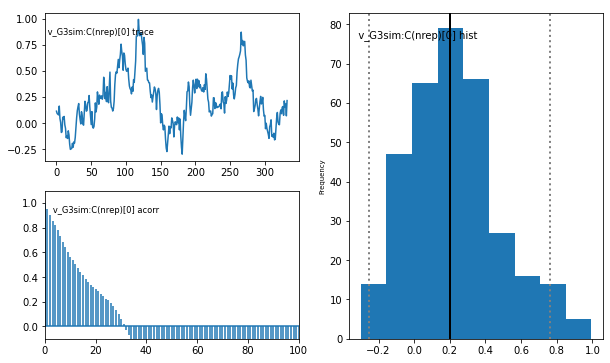

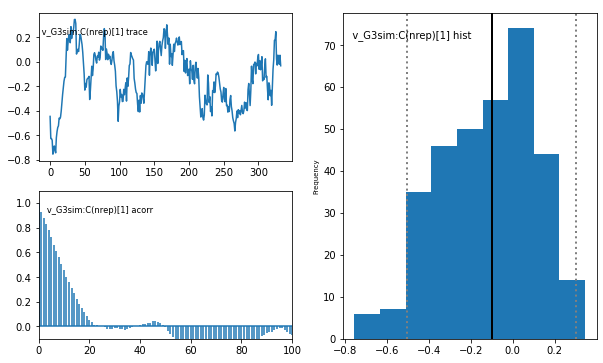

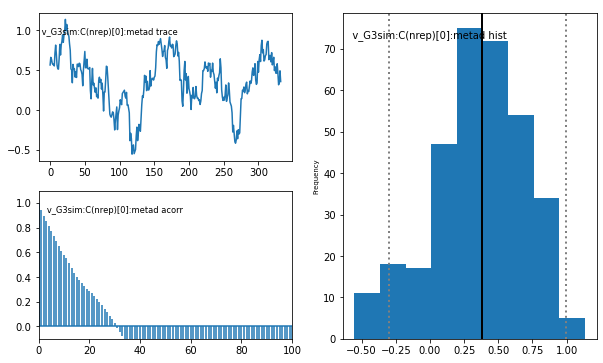

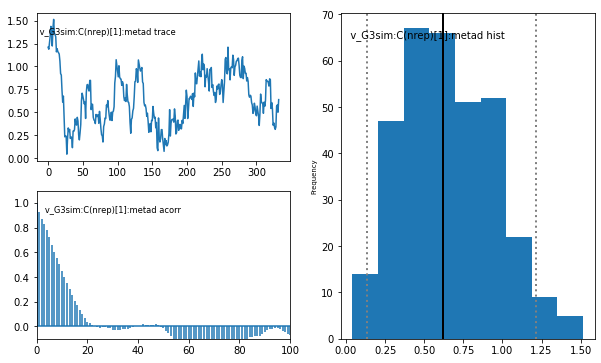

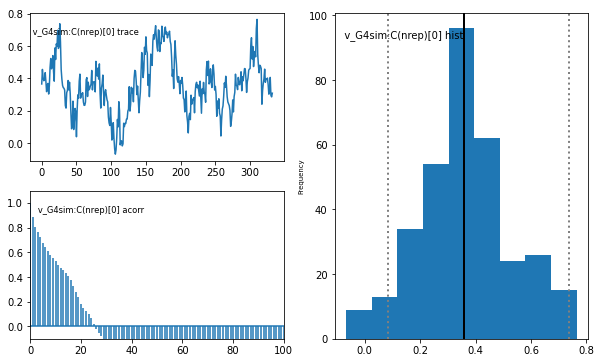

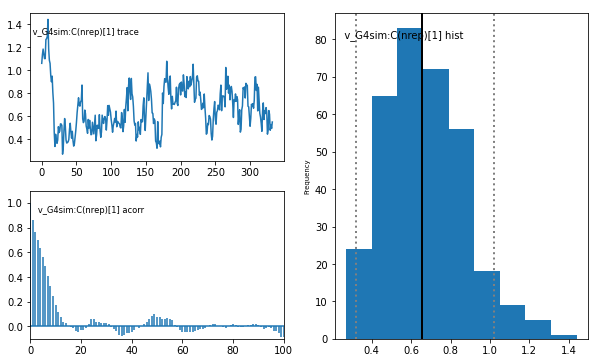

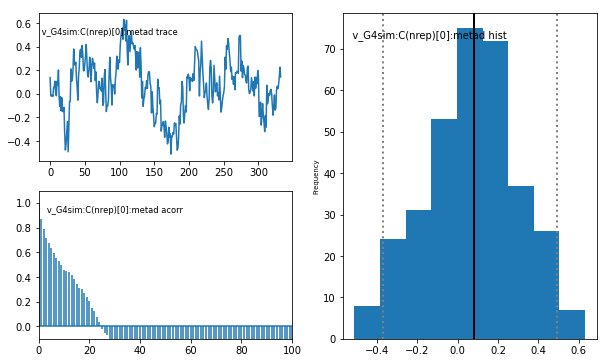

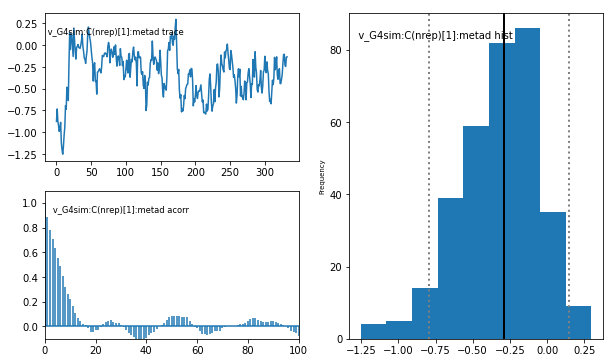

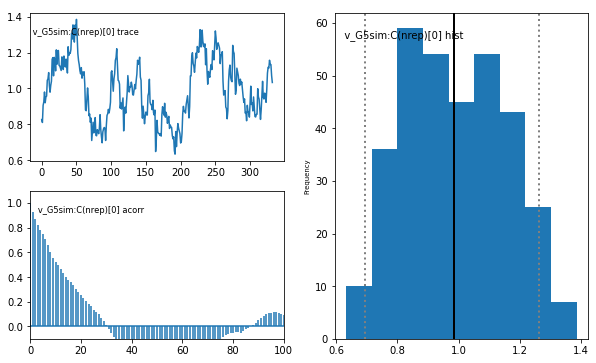

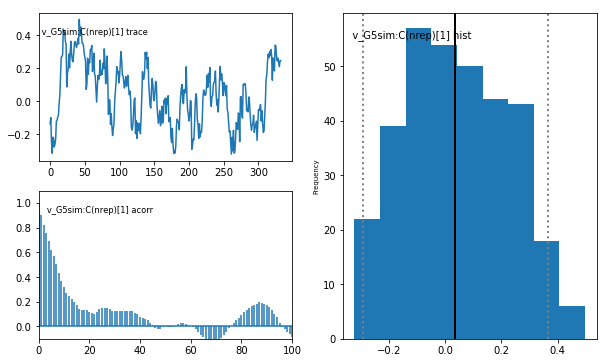

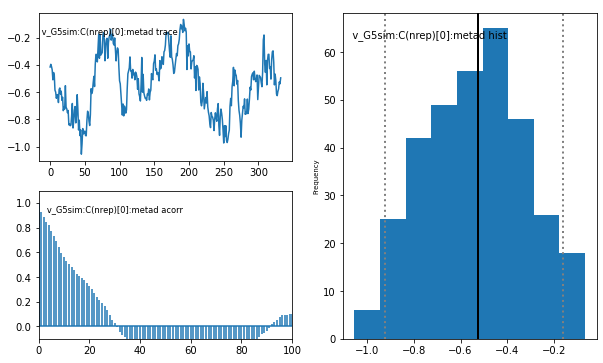

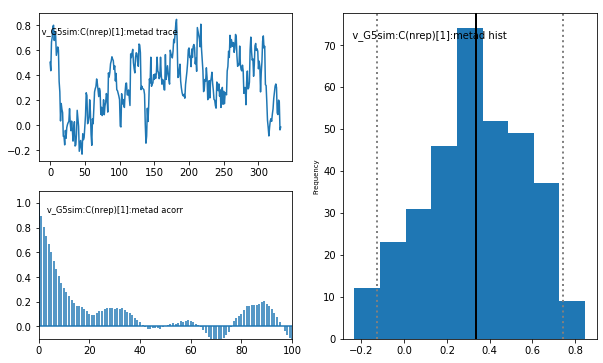

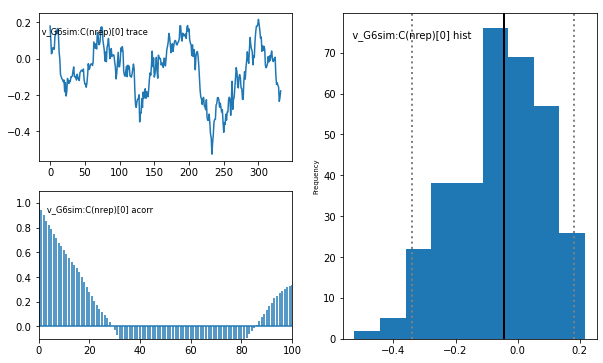

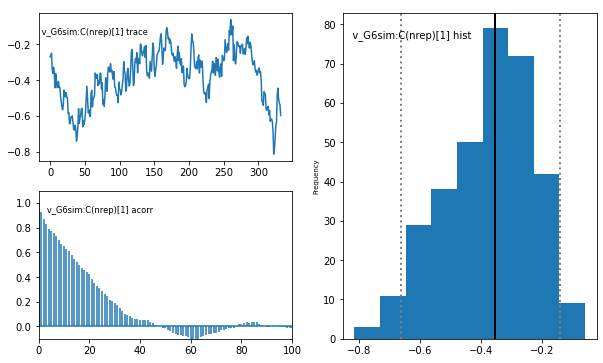

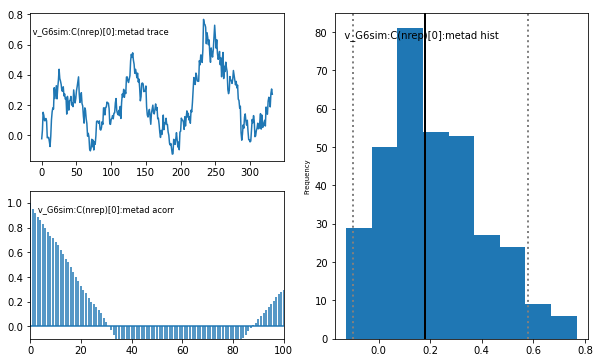

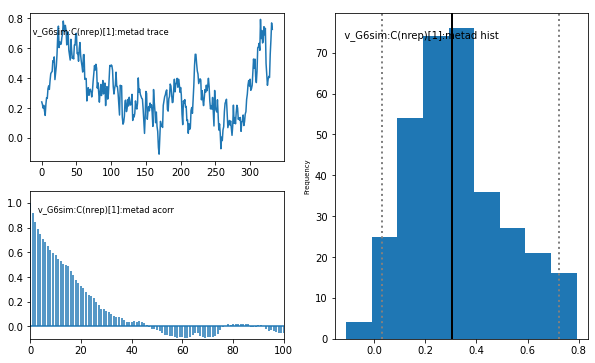

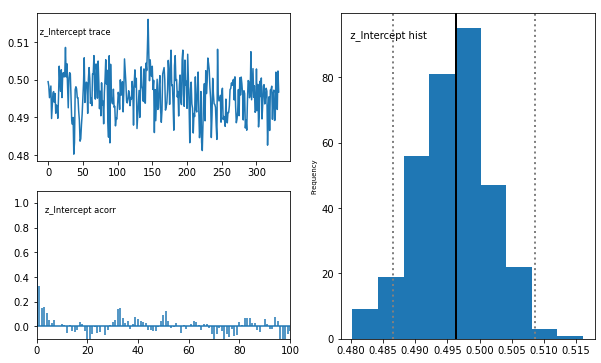

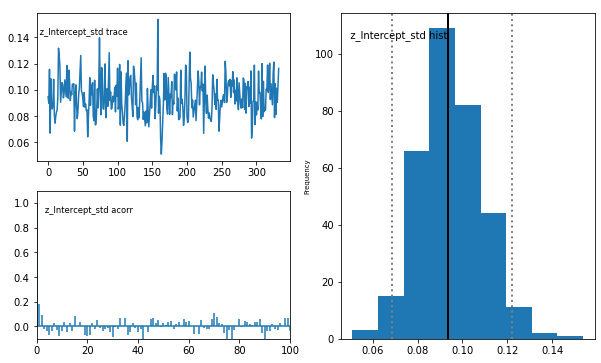

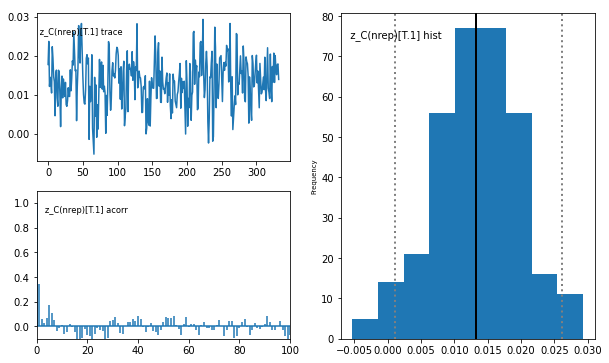

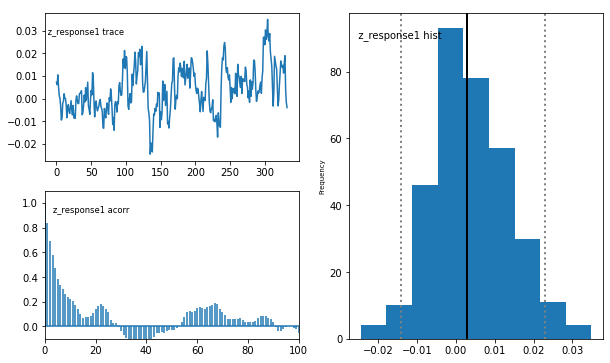

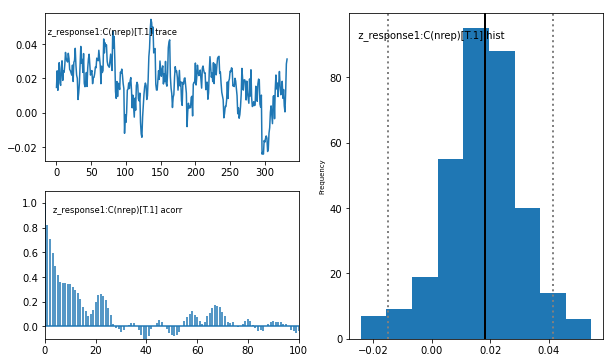

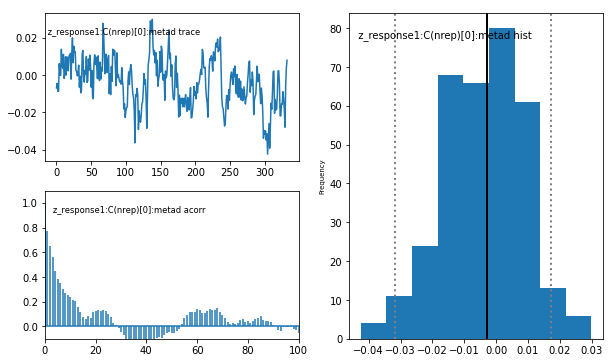

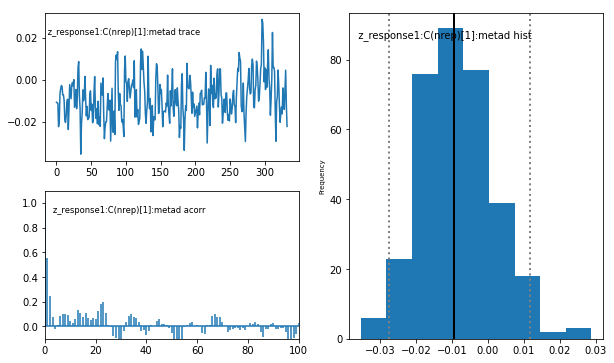

In [107]:
z_v_prevrespmetad.plot_posteriors()

## 3 repslag experiment

In [110]:
dat = mydata[mydata.exp_ID == '3reps_lag']
dat.reset_index(inplace = True, drop = True)
dat['nrep'] = dat['nrep'].cat.remove_unused_categories()
dat['subj_idx'] = dat['subj_idx'].cat.remove_unused_categories()
exp_ID = '3reps_lag' 

<ipython-input-110-ed1767fdb1b1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['nrep'] = dat['nrep'].cat.remove_unused_categories()
<ipython-input-110-ed1767fdb1b1>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subj_idx'] = dat['subj_idx'].cat.remove_unused_categories()


__Model with weight for each stimulus__

In [109]:
def z_link_func(x, data=dat):
    stim = (np.asarray(dmatrix('0 + C(s, [[0], [1]])',
                              {'s': data.stimulus.loc[x.index]},return_type='dataframe'))
    )
    # Apply z = (1 - x) to flip them along 0.5
    z_flip = np.subtract(stim, x.to_frame())
    # The above inverts those values we do not want to flip,
    # so invert them back
    z_flip[stim == 0] *= -1
    return z_flip

In [19]:
z_reg = {'model': 'z ~ 1 + response1 * C(nrep)', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1abs:C(nrep) + G2abs:C(nrep) +G3abs:C(nrep)+G4abs:C(nrep)+G5abs:C(nrep)+G6abs:C(nrep)', 'link_func': lambda x: x}
reg_descr = [z_reg, v_reg]


In [20]:
n_samples = 2000
model_name = 'stimcoding_weights'


In [21]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

Run model and save it

In [37]:
m_reg_3reps_lagstimweights = hddm.HDDMRegressor(dat, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).


Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_C(nrep)[T.2]', 'z_response1', 'z_response1:C(nrep)[T.1]', 'z_response1:C(nrep)[T.2]']
Adding these covariates:
['v_Intercept', 'v_G1abs:C(nrep)[0]', 'v_G1abs:C(nrep)[1]', 'v_G1abs:C(nrep)[2]', 'v_G2abs:C(nrep)[0]', 'v_G2abs:C(nrep)[1]', 'v_G2abs:C(nrep)[2]', 'v_G3abs:C(nrep)[0]', 'v_G3abs:C(nrep)[1]', 'v_G3abs:C(nrep)[2]', 'v_G4abs:C(nrep)[0]', 'v_G4abs:C(nrep)[1]', 'v_G4abs:C(nrep)[2]', 'v_G5abs:C(nrep)[0]', 'v_G5abs:C(nrep)[1]', 'v_G5abs:C(nrep)[2]', 'v_G6abs:C(nrep)[0]', 'v_G6abs:C(nrep)[1]', 'v_G6abs:C(nrep)[2]']


In [38]:

m_reg_3reps_lagstimweights.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

m_reg_3reps_lagstimweights.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 26560.8 secWARNING: Will not save custom link functions.


In [42]:
m_reg_3reps_lagstimweights.print_stats()

                                 mean          std         2.5q          25q          50q          75q        97.5q       mc err
a                             1.96592    0.0597926      1.83936       1.9273      1.96621       2.0053      2.08973   0.00353536
a_std                        0.334519    0.0430416     0.263362     0.304177     0.328545     0.359164     0.442276   0.00230099
a_subj.68                     1.37953    0.0345181       1.3186       1.3548      1.38031      1.40293      1.44657   0.00193282
a_subj.69                     2.32201    0.0684754      2.16808      2.28141      2.32346      2.36827      2.45377   0.00463916
a_subj.70                     1.96225    0.0486431      1.87204      1.92517      1.95887      1.99682      2.06445   0.00294465
a_subj.71                     3.27312    0.0887365      3.11311      3.20818      3.26988      3.32699      3.46069   0.00528602
a_subj.72                     1.91336    0.0471214       1.8247      1.88071      1.91205      1.

__Model with weight for each stimulus as a function of dv distance to previous decision__

In [22]:
z_reg = {'model': 'z ~ 1 + response1 * C(nrep)', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1sim:C(nrep) + G2sim:C(nrep) +G3sim:C(nrep)+G4sim:C(nrep)+G5sim:C(nrep)+G6sim:C(nrep)', 'link_func': lambda x: x}
reg_descr = [z_reg, v_reg]

In [23]:
n_samples = 2000
model_name = 'stimcoding_diffprev'


In [24]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [66]:
#m_reg_3repslagprevabs = hddm.load(model_filename+'_fm.db')

In [25]:
m_reg_3repslagprevabs = hddm.HDDMRegressor(dat, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).


Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_C(nrep)[T.2]', 'z_response1', 'z_response1:C(nrep)[T.1]', 'z_response1:C(nrep)[T.2]']
Adding these covariates:
['v_Intercept', 'v_G1sim:C(nrep)[0]', 'v_G1sim:C(nrep)[1]', 'v_G1sim:C(nrep)[2]', 'v_G2sim:C(nrep)[0]', 'v_G2sim:C(nrep)[1]', 'v_G2sim:C(nrep)[2]', 'v_G3sim:C(nrep)[0]', 'v_G3sim:C(nrep)[1]', 'v_G3sim:C(nrep)[2]', 'v_G4sim:C(nrep)[0]', 'v_G4sim:C(nrep)[1]', 'v_G4sim:C(nrep)[2]', 'v_G5sim:C(nrep)[0]', 'v_G5sim:C(nrep)[1]', 'v_G5sim:C(nrep)[2]', 'v_G6sim:C(nrep)[0]', 'v_G6sim:C(nrep)[1]', 'v_G6sim:C(nrep)[2]']


In [184]:

m_reg_3repslagprevabs.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

m_reg_3repslagprevabs.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 25563.9 secWARNING: Will not save custom link functions.


In [41]:
m_reg_3repslagprevabs.print_stats()


NameError: name 'm_reg_3repslagprevabs' is not defined

__Model with weight for each stimulus as a function of dv distance to previous decision and lag__

In [111]:
z_reg = {'model': 'z ~ 1 + C(nrep)*response1+C(nrep):response1:ITI', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1sim:C(nrep) + G1sim:C(nrep):ITI + G2sim:C(nrep) + G2sim:C(nrep):ITI +G3sim:C(nrep)+ G3sim:C(nrep):ITI+G4sim:C(nrep)+ G4sim:C(nrep):ITI + G5sim:C(nrep)+ G5sim:C(nrep):ITI+G6sim:C(nrep) + G6sim:C(nrep):ITI', 'link_func': lambda x: x}
reg_descr = [z_reg, v_reg]

In [112]:
n_samples = 2000
model_name = 'stimcoding_diffprev_lags'


In [113]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [66]:
#m_reg_3repslagprevabs = hddm.load(model_filename+'_fm.db')

In [114]:
m_reg_3repslagprevabs_lags = hddm.HDDMRegressor(dat, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).


Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_C(nrep)[T.2]', 'z_response1', 'z_C(nrep)[T.1]:response1', 'z_C(nrep)[T.2]:response1', 'z_C(nrep)[0]:response1:ITI[T.3500.0]', 'z_C(nrep)[1]:response1:ITI[T.3500.0]', 'z_C(nrep)[2]:response1:ITI[T.3500.0]']
Adding these covariates:
['v_Intercept', 'v_G1sim:C(nrep)[0]', 'v_G1sim:C(nrep)[1]', 'v_G1sim:C(nrep)[2]', 'v_G1sim:C(nrep)[0]:ITI[T.3500.0]', 'v_G1sim:C(nrep)[1]:ITI[T.3500.0]', 'v_G1sim:C(nrep)[2]:ITI[T.3500.0]', 'v_G2sim:C(nrep)[0]', 'v_G2sim:C(nrep)[1]', 'v_G2sim:C(nrep)[2]', 'v_G2sim:C(nrep)[0]:ITI[T.3500.0]', 'v_G2sim:C(nrep)[1]:ITI[T.3500.0]', 'v_G2sim:C(nrep)[2]:ITI[T.3500.0]', 'v_G3sim:C(nrep)[0]', 'v_G3sim:C(nrep)[1]', 'v_G3sim:C(nrep)[2]', 'v_G3sim:C(nrep)[0]:ITI[T.3500.0]', 'v_G3sim:C(nrep)[1]:ITI[T.3500.0]', 'v_G3sim:C(nrep)[2]:ITI[T.3500.0]', 'v_G4sim:C(nrep)[0]', 'v_G4sim:C(nrep)[1]', 'v_G4sim:C(nrep)[2]', 'v_G4sim:C(nrep)[0]:ITI[T.3500.0]', 'v_G4sim:C(nrep)[1]:ITI[T.3500.0]', 'v_G4sim:C(nrep)[2]:ITI[T.3500.

In [115]:
m_reg_3repslagprevabs_lags.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

m_reg_3repslagprevabs_lags.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 84997.1 secWARNING: Will not save custom link functions.


In [117]:
m_reg_3repslagprevabs_lags.print_stats()


                                             mean          std         2.5q          25q          50q          75q        97.5q       mc err
a                                          1.9696    0.0579893       1.8652      1.93014      1.96724      2.00744      2.09172   0.00322793
a_std                                    0.338089    0.0458125     0.262297     0.307456     0.336583     0.360792     0.434536    0.0025343
a_subj.68                                 1.37804    0.0362615      1.31574      1.35113      1.37711      1.40305       1.4521   0.00208145
a_subj.69                                 2.33194    0.0638673      2.19405       2.2936      2.33416      2.37008      2.45533   0.00429909
a_subj.70                                 1.96604    0.0467231      1.87409      1.93314      1.96735      1.99681      2.06095   0.00274102
a_subj.71                                 3.27129    0.0848886      3.10739      3.21954      3.27615      3.32628      3.44433   0.00501609
a_subj.72    

## 3 diffs experiment

In [79]:
dat = mydata[mydata.exp_ID == '3diffs']
dat.reset_index(inplace = True, drop = True)
dat['nrep'] = dat['nrep'].cat.remove_unused_categories()
dat['subj_idx'] = dat['subj_idx'].cat.remove_unused_categories()
exp_ID = '3diffs' 

<ipython-input-79-3954265fd71a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['nrep'] = dat['nrep'].cat.remove_unused_categories()
<ipython-input-79-3954265fd71a>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subj_idx'] = dat['subj_idx'].cat.remove_unused_categories()


__Model with weight for each stimulus__

In [80]:
def z_link_func(x, data=dat):
    stim = (np.asarray(dmatrix('0 + C(s, [[0], [1]])',
                              {'s': data.stimulus.loc[x.index]},return_type='dataframe'))
    )
    # Apply z = (1 - x) to flip them along 0.5
    z_flip = np.subtract(stim, x.to_frame())
    # The above inverts those values we do not want to flip,
    # so invert them back
    z_flip[stim == 0] *= -1
    return z_flip

In [81]:
z_reg = {'model': 'z ~ 1 + response1 * C(nrep)', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1abs:C(nrep) + G2abs:C(nrep) +G3abs:C(nrep)+G4abs:C(nrep)+G5abs:C(nrep)+G6abs:C(nrep)', 'link_func': lambda x: x}
reg_descr = [z_reg, v_reg]


In [82]:
n_samples = 2000
model_name = 'stimcoding_weights'


In [52]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

Run model and save it

In [53]:
m_reg_3diffstimweights = hddm.HDDMRegressor(dat, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).


Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_response1', 'z_response1:C(nrep)[T.1]']
Adding these covariates:
['v_Intercept', 'v_G1abs:C(nrep)[0]', 'v_G1abs:C(nrep)[1]', 'v_G2abs:C(nrep)[0]', 'v_G2abs:C(nrep)[1]', 'v_G3abs:C(nrep)[0]', 'v_G3abs:C(nrep)[1]', 'v_G4abs:C(nrep)[0]', 'v_G4abs:C(nrep)[1]', 'v_G5abs:C(nrep)[0]', 'v_G5abs:C(nrep)[1]', 'v_G6abs:C(nrep)[0]', 'v_G6abs:C(nrep)[1]']


In [ ]:

m_reg_3diffstimweights.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

m_reg_3diffstimweights.save(model_filename+'_fm.db') # save the model to disk

In [ ]:
m_reg_3diffsimweights.print_stats()

__Model with weight for each stimulus as a function of dv distance to previous decision__

In [93]:
dat

,exp_ID,subj_idx,npar,subj,nblock,ntrial,nrep,rep,stimuli1,stimulus,rDV,response3,response2,response1,RepResponses,DV,response,SideResp1,SideResp,RepSideResp,r_map,accuracy1,accuracy,rt,d1,d2,d3,d4,d5,d6,o1,o2,o3,o4,o5,o6,Confidence1,trial_type,Confidence,metad,metad_3%,metad_97%,ITI,G1sim,G2sim,G3sim,G4sim,G5sim,G6sim,G1abs,G2abs,G3abs,G4abs,G5abs,G6abs
0,3diffs,1,1,020621150004E,0,0,0,diff,0,1,0.185048,0,0,-1,0,0.16667,1,R,R,1,0,0,1,1.646,-0.022671,0.566085,-0.622602,0.398017,0.095505,0.695955,1.187,0.615,1.719,0.549,2.001,0.666,NaN,nonrepeat,NaN,NaN,NaN,NaN,NaN,0.622602,0.022671,0.095505,0.398017,0.566085,0.695955,0.622602,0.022671,0.095505,0.398017,0.566085,0.695955
1,3diffs,1,1,020621150004E,0,0,1,diff,1,1,0.159410,0,0,1,0,0.16667,0,R,R,1,45,1,0,3.290,0.502941,0.061363,0.851290,-0.801375,0.147943,0.194299,2.161,1.154,0.727,0.078,1.120,0.469,NaN,nonrepeat,NaN,NaN,NaN,NaN,NaN,0.851290,0.502941,0.194299,0.147943,0.061363,0.801375,0.851290,0.502941,0.194299,0.147943,0.061363,0.801375
2,3diffs,1,1,020621150004E,0,0,2,diff,1,1,0.178250,0,1,-1,1,0.16667,0,R,R,1,45,0,0,1.412,0.711753,0.784045,-0.302265,-0.435200,0.583391,-0.272226,2.243,2.441,0.274,1.349,0.949,1.285,NaN,nonrepeat,NaN,NaN,NaN,NaN,NaN,0.435200,0.302265,0.272226,0.583391,0.711753,0.784045,0.435200,0.302265,0.272226,0.583391,0.711753,0.784045
3,3diffs,1,1,020621150004E,0,1,0,diff,1,1,0.050171,1,0,-1,0,0.06667,1,R,R,1,0,0,1,1.421,0.066975,-0.660800,0.452012,0.134692,0.851809,-0.543662,0.419,1.704,2.141,2.696,2.298,1.750,NaN,nonrepeat,NaN,NaN,NaN,NaN,NaN,0.660800,0.543662,0.066975,0.134692,0.452012,0.851809,0.660800,0.543662,0.066975,0.134692,0.452012,0.851809
4,3diffs,1,1,020621150004E,0,1,1,diff,1,1,0.089799,0,0,1,1,0.06667,1,R,R,1,0,1,1,0.770,-0.063414,0.780508,0.771831,-0.761668,-0.717859,0.529397,1.203,2.270,0.875,3.048,1.460,2.541,NaN,nonrepeat,NaN,NaN,NaN,NaN,NaN,0.780508,0.771831,0.529397,0.063414,0.717859,0.761668,0.780508,0.771831,0.529397,0.063414,0.717859,0.761668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16941,3diffs,25,26,301020114702,5,38,1,diff,1,1,0.305063,0,1,-1,0,0.31000,1,L,R,0,0,0,1,0.608,0.975549,-0.738750,0.723448,-0.747899,0.826344,0.791684,0.795,3.039,0.894,0.099,2.288,2.438,NaN,nonrepeat,NaN,NaN,NaN,NaN,NaN,0.747899,0.738750,0.723448,0.791684,0.826344,0.975549,0.747899,0.738750,0.723448,0.791684,0.826344,0.975549
16942,3diffs,25,26,301020114702,5,38,2,diff,1,1,0.331125,1,0,1,1,0.31000,1,R,R,1,0,1,1,0.544,0.551324,0.523313,0.686288,0.850253,-0.585961,-0.038468,2.180,2.169,2.233,2.415,2.979,2.764,NaN,nonrepeat,NaN,NaN,NaN,NaN,NaN,0.850253,0.686288,0.551324,0.523313,0.038468,0.585961,0.850253,0.686288,0.551324,0.523313,0.038468,0.585961
16943,3diffs,25,26,301020114702,5,39,0,diff,1,0,-0.400815,0,1,1,0,-0.41000,0,R,R,1,45,1,1,0.449,-0.612417,-0.130141,-0.882343,-0.180552,-0.220259,-0.379178,1.723,2.800,1.617,1.249,1.877,1.327,NaN,nonrepeat,NaN,NaN,NaN,NaN,NaN,0.130141,0.180552,0.220259,0.379178,0.612417,0.882343,0.130141,0.180552,0.220259,0.379178,0.612417,0.882343
16944,3diffs,25,26,301020114702,5,39,1,diff,0,0,-0.390888,1,1,-1,1,-0.41000,0,R,R,1,45,1,1,0.334,0.380710,-0.682209,-0.811561,-0.102130,-0.516169,-0.613972,2.113,1.446,0.074,2.789,0.190,2.990,NaN,nonrepeat,NaN,NaN,NaN,NaN,NaN,0.811561,0.682209,0.613972,0.516169,0.102130,0.380710,0.811561,0.682209,0.613972,0.516169,0.102130,0.380710


In [87]:
z_reg = {'model': 'z ~ 1 + response1 * C(nrep)', 'link_func': z_link_func}
v_reg = {'model': 'v ~ 1 + G1sim:C(nrep) + G2sim:C(nrep) +G3sim:C(nrep)+G4sim:C(nrep)+G5sim:C(nrep)+G6sim:C(nrep)', 'link_func': lambda x: x}
reg_descr = [z_reg, v_reg]

In [88]:
n_samples = 2000
model_name = 'stimcoding_diffprev'


In [89]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name+'_'+exp_ID)

In [66]:
#m_reg_3repslagprevabs = hddm.load(model_filename+'_fm.db')

In [90]:
m_reg_3diffslagprevabs = hddm.HDDMRegressor(dat, reg_descr, include=['v', 'a', 't', 'z'])
#Now we start the model, and wait for a while (you can go and get several coffees, or read a paper).


Adding these covariates:
['z_Intercept', 'z_C(nrep)[T.1]', 'z_C(nrep)[T.2]', 'z_response1', 'z_response1:C(nrep)[T.1]', 'z_response1:C(nrep)[T.2]']
Adding these covariates:
['v_Intercept', 'v_G1sim:C(nrep)[0]', 'v_G1sim:C(nrep)[1]', 'v_G1sim:C(nrep)[2]', 'v_G2sim:C(nrep)[0]', 'v_G2sim:C(nrep)[1]', 'v_G2sim:C(nrep)[2]', 'v_G3sim:C(nrep)[0]', 'v_G3sim:C(nrep)[1]', 'v_G3sim:C(nrep)[2]', 'v_G4sim:C(nrep)[0]', 'v_G4sim:C(nrep)[1]', 'v_G4sim:C(nrep)[2]', 'v_G5sim:C(nrep)[0]', 'v_G5sim:C(nrep)[1]', 'v_G5sim:C(nrep)[2]', 'v_G6sim:C(nrep)[0]', 'v_G6sim:C(nrep)[1]', 'v_G6sim:C(nrep)[2]']


In [91]:

m_reg_3diffslagprevabs.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')

m_reg_3diffslagprevabs.save(model_filename+'_fm.db') # save the model to disk

 [-----------------100%-----------------] 2001 of 2000 complete in 34383.2 secWARNING: Will not save custom link functions.


In [92]:
m_reg_3diffslagprevabs.print_stats()


                                 mean          std         2.5q          25q          50q          75q        97.5q       mc err
a                             1.54325    0.0473054      1.46054      1.51425      1.53944      1.57166      1.64538   0.00259401
a_std                        0.223114    0.0368879     0.165677     0.197079     0.219086     0.244653     0.306257   0.00211885
a_subj.1                      1.70793    0.0354429      1.64723      1.68057      1.70739      1.73611      1.77414   0.00211762
a_subj.2                      1.84418    0.0405167        1.767      1.81663      1.84561      1.87125      1.92647   0.00246997
a_subj.3                       1.4513    0.0271222      1.39736      1.43329      1.45202      1.47011      1.50568   0.00162359
a_subj.4                      1.25963    0.0251005      1.20945      1.24409      1.25906      1.27694      1.31201   0.00152976
a_subj.5                      1.48483    0.0269402      1.43223      1.46595        1.486      1.

In [ ]:

def make_model(mypath, mydata, model_name, trace_id):

    model_filename  = os.path.join(mypath, model_name, 'modelfit-md%d.model'%trace_id)
    print model_filename

    # ============================================ #
    # NO HISTORY FOR MODEL COMPARISON
    # ============================================ #

    if model_name == 'stimcoding_nohist':

        # get the right variable coding
        mydata = recode_4stimcoding(mydata)

        # for Anke's data, also split by transition probability
        if len(mydata.coherence.unique()) > 1:
            m = hddm.HDDMStimCoding(mydata, stim_col='stimulus', split_param='v',
                drift_criterion=True, bias=True, p_outlier=0.05,
                include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                depends_on={'v': ['coherence']})
        else:
            m = hddm.HDDMStimCoding(mydata, stim_col='stimulus', split_param='v',
                drift_criterion=True, bias=True, p_outlier=0.05,
                include=('sv', 'sz'), group_only_nodes=['sv', 'sz'])

    # ============================================ #